<a href="https://colab.research.google.com/github/kjcline-spec/DNSC-6330-Responsible-Machine-Learning/blob/main/HW_4%265_KJ_Cline_COMPAS_Analysis_Python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Loading the Data

We select fields for severity of charge, number of priors, demographics, age, sex, compas scores,
and whether each person was accused of a crime within two years.

In [1]:
# ── Imports ───────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
import math
import warnings
from scipy import stats

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120
sns.set_style('whitegrid')

print('Libraries loaded.')

Libraries loaded.


In [2]:
# ── Load raw data ─────────────────────────────────────────────────────────────
# R: raw_data <- read.csv(url, stringsAsFactors = FALSE)

url = "https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv"
raw_data = pd.read_csv(url)

print(f"Raw rows: {len(raw_data)}")   # Expect 7214

Raw rows: 7214


In [3]:
# ── Preview ───────────────────────────────────────────────────────────────────
# R: head(raw_data, 10)
raw_data.head(10)

,id,name,first,last,compas_screening_date,sex,dob,age,age_cat,race,...,v_decile_score,v_score_text,v_screening_date,in_custody,out_custody,priors_count.1,start,end,event,two_year_recid
0,1,miguel hernandez,miguel,hernandez,2013-08-14,Male,1947-04-18,69,Greater than 45,Other,...,1,Low,2013-08-14,2014-07-07,2014-07-14,0,0,327,0,0
1,3,kevon dixon,kevon,dixon,2013-01-27,Male,1982-01-22,34,25 - 45,African-American,...,1,Low,2013-01-27,2013-01-26,2013-02-05,0,9,159,1,1
2,4,ed philo,ed,philo,2013-04-14,Male,1991-05-14,24,Less than 25,African-American,...,3,Low,2013-04-14,2013-06-16,2013-06-16,4,0,63,0,1
3,5,marcu brown,marcu,brown,2013-01-13,Male,1993-01-21,23,Less than 25,African-American,...,6,Medium,2013-01-13,NaN,NaN,1,0,1174,0,0
4,6,bouthy pierrelouis,bouthy,pierrelouis,2013-03-26,Male,1973-01-22,43,25 - 45,Other,...,1,Low,2013-03-26,NaN,NaN,2,0,1102,0,0
5,7,marsha miles,marsha,miles,2013-11-30,Male,1971-08-22,44,25 - 45,Other,...,1,Low,2013-11-30,2013-11-30,2013-12-01,0,1,853,0,0
6,8,edward riddle,edward,riddle,2014-02-19,Male,1974-07-23,41,25 - 45,Caucasian,...,2,Low,2014-02-19,2014-03-31,2014-04-18,14,5,40,1,1
7,9,steven stewart,steven,stewart,2013-08-30,Male,1973-02-25,43,25 - 45,Other,...,3,Low,2013-08-30,2014-05-22,2014-06-03,3,0,265,0,0
8,10,elizabeth thieme,elizabeth,thieme,2014-03-16,Female,1976-06-03,39,25 - 45,Caucasian,...,1,Low,2014-03-16,2014-03-15,2014-03-18,0,2,747,0,0
9,13,bo bradac,bo,bradac,2013-11-04,Male,1994-06-10,21,Less than 25,Caucasian,...,5,Medium,2013-11-04,2015-01-06,2015-01-07,1,0,428,1,1


However not all of the rows are useable for the first round of analysis.

There are a number of reasons to remove rows because of missing data:
* If the charge date of a defendant's COMPAS scored crime was not within 30 days from when the person was arrested, we assume that because of data quality reasons, we do not have the right offense.
* We coded the recidivist flag -- `is_recid` -- to be -1 if we could not find a COMPAS case at all.
* Ordinary traffic offenses -- those with a `c_charge_degree` of 'O' -- will not result in jail time and are removed.
* We filtered to include only those rows representing people who had either recidivated in two years, or had at least two years outside of a correctional facility.

In [4]:
# ── Select columns, filter, convert types, build derived factor variables ─────
# R: dplyr::select(...) %>% filter(...) %>% mutate(across(...)) %>% mutate(relevel(...))

numeric_vars  = ['age', 'priors_count', 'days_b_screening_arrest', 'decile_score']
datetime_vars = ['c_jail_in', 'c_jail_out']

cols = [
    'age', 'c_charge_degree', 'race', 'age_cat', 'score_text', 'sex',
    'priors_count', 'days_b_screening_arrest', 'decile_score',
    'is_recid', 'two_year_recid', 'c_jail_in', 'c_jail_out'
]

df = (
    raw_data[cols].copy()
    # ── Filtering ──────────────────────────────────────────────────────
    .query("days_b_screening_arrest >= -30 and days_b_screening_arrest <= 30")
    .query("is_recid != -1")
    .query("c_charge_degree != 'O'")
    .query("score_text != 'N/A'")
    .reset_index(drop=True)
)

# ── Type conversions ───────────────────────────────────────────────────
for col in datetime_vars:
    df[col] = pd.to_datetime(df[col], format='%Y-%m-%d %H:%M:%S', errors='coerce')

# ── Derived factors with reference levels (mirrors R relevel) ─────────
# age_factor:    ref = '25 - 45'
# race_factor:   ref = 'Caucasian'
# gender_factor: ref = 'Male'
# crime_factor:  ref = 'F' (felony)
# score_factor:  LowScore vs HighScore

df['crime_factor']  = pd.Categorical(df['c_charge_degree'],
                                     categories=['F', 'M'])
df['age_factor']    = pd.Categorical(df['age_cat'],
                                     categories=['25 - 45', 'Greater than 45', 'Less than 25'])
df['race_factor']   = pd.Categorical(df['race'],
                                     categories=['Caucasian', 'African-American', 'Asian',
                                                 'Hispanic', 'Native American', 'Other'])
df['gender_factor'] = pd.Categorical(df['sex'],
                                     categories=['Male', 'Female'])
df['score_factor']  = pd.Categorical(
    np.where(df['score_text'] != 'Low', 'HighScore', 'LowScore'),
    categories=['LowScore', 'HighScore']
)

print(f"Filtered rows: {len(df)}")   # Expect 6172

Filtered rows: 6172


In [5]:
# ── head(df) ──────────────────────────────────────────────────────────────────
df.head()

,age,c_charge_degree,race,age_cat,score_text,sex,priors_count,days_b_screening_arrest,decile_score,is_recid,two_year_recid,c_jail_in,c_jail_out,crime_factor,age_factor,race_factor,gender_factor,score_factor
0,69,F,Other,Greater than 45,Low,Male,0,-1.0,1,0,0,2013-08-13 06:03:42,2013-08-14 05:41:20,F,Greater than 45,Other,Male,LowScore
1,34,F,African-American,25 - 45,Low,Male,0,-1.0,3,1,1,2013-01-26 03:45:27,2013-02-05 05:36:53,F,25 - 45,African-American,Male,LowScore
2,24,F,African-American,Less than 25,Low,Male,4,-1.0,4,1,1,2013-04-13 04:58:34,2013-04-14 07:02:04,F,Less than 25,African-American,Male,LowScore
3,44,M,Other,25 - 45,Low,Male,0,0.0,1,0,0,2013-11-30 04:50:18,2013-12-01 12:28:56,M,25 - 45,Other,Male,LowScore
4,41,F,Caucasian,25 - 45,Medium,Male,14,-1.0,6,1,1,2014-02-18 05:08:24,2014-02-24 12:18:30,F,25 - 45,Caucasian,Male,HighScore


In [6]:
# ── glimpse(df) ───────────────────────────────────────────────────────────────
# R: glimpse(df)
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
df.info()

Rows: 6172, Columns: 18
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6172 entries, 0 to 6171
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   age                      6172 non-null   int64         
 1   c_charge_degree          6172 non-null   object        
 2   race                     6172 non-null   object        
 3   age_cat                  6172 non-null   object        
 4   score_text               6172 non-null   object        
 5   sex                      6172 non-null   object        
 6   priors_count             6172 non-null   int64         
 7   days_b_screening_arrest  6172 non-null   float64       
 8   decile_score             6172 non-null   int64         
 9   is_recid                 6172 non-null   int64         
 10  two_year_recid           6172 non-null   int64         
 11  c_jail_in                6172 non-null   datetime64[ns]
 12  c_jail_out

Higher COMPAS scores are slightly correlated with a longer length of stay.

In [7]:
# ── Correlation: length of stay vs decile score ───────────────────────────────
# R: df$length_of_stay <- as.numeric(...); cor(df$length_of_stay, df$decile_score)

df['length_of_stay'] = (df['c_jail_out'] - df['c_jail_in']).dt.days

valid = df[['length_of_stay', 'decile_score']].dropna()
r, _ = stats.pearsonr(valid['length_of_stay'], valid['decile_score'])
print(f"Correlation (length_of_stay vs decile_score): {r:.7f}")   # Expect ~0.207

Correlation (length_of_stay vs decile_score): 0.2074781


After filtering we have the following demographic breakdown:

In [8]:
# ── Age category breakdown ────────────────────────────────────────────────────
# R: summary(df$age_cat)
print(df['age_cat'].value_counts().sort_index())

age_cat
25 - 45            3532
Greater than 45    1293
Less than 25       1347
Name: count, dtype: int64


In [9]:
# ── Race breakdown ────────────────────────────────────────────────────────────
# R: summary(df$race)
print(df['race'].value_counts())

race
African-American    3175
Caucasian           2103
Hispanic             509
Other                343
Asian                 31
Native American       11
Name: count, dtype: int64


In [10]:
# ── Race percentages ──────────────────────────────────────────────────────────
n = len(df)
rc = df['race'].value_counts()

print(f"Black defendants:           {rc.get('African-American', 0) / n * 100:.2f}%")
print(f"White defendants:           {rc.get('Caucasian', 0)        / n * 100:.2f}%")
print(f"Hispanic defendants:        {rc.get('Hispanic', 0)         / n * 100:.2f}%")
print(f"Asian defendants:           {rc.get('Asian', 0)            / n * 100:.2f}%")
print(f"Native American defendants: {rc.get('Native American', 0)  / n * 100:.2f}%")

Black defendants:           51.44%
White defendants:           34.07%
Hispanic defendants:        8.25%
Asian defendants:           0.50%
Native American defendants: 0.18%


In [11]:
# ── Score text distribution ───────────────────────────────────────────────────
# R: summary(df$score_text)
print(df['score_text'].value_counts())

score_text
Low       3421
Medium    1607
High      1144
Name: count, dtype: int64


In [12]:
# ── Cross-tab: sex × race ─────────────────────────────────────────────────────
# R: xtabs(~ sex + race, data=df)
pd.crosstab(df['sex'], df['race'])

race,African-American,Asian,Caucasian,Hispanic,Native American,Other
sex,,,,,,
Female,549,2,482,82,2,58
Male,2626,29,1621,427,9,285


In [13]:
# ── Sex distribution and percentages ─────────────────────────────────────────
# R: summary(df$sex)
sc = df['sex'].value_counts()
print(sc)
print(f"\nMen:   {sc.get('Male',   0) / n * 100:.2f}%")
print(f"Women: {sc.get('Female', 0) / n * 100:.2f}%")

sex
Male      4997
Female    1175
Name: count, dtype: int64

Men:   80.96%
Women: 19.04%


In [14]:
# ── Two-year recidivism count and rate ────────────────────────────────────────
# R: nrow(filter(df, two_year_recid == 1))
#    nrow(filter(df, two_year_recid == 1)) / nrow(df) * 100

recid_count = (df['two_year_recid'] == 1).sum()
print(f"Two-year recidivists: {recid_count}")
print(f"Recidivism rate:      {recid_count / n * 100:.2f}%")

Two-year recidivists: 2809
Recidivism rate:      45.51%


Judges are often presented with two sets of scores from the COMPAS system — one that classifies people into High, Medium and Low risk, and a corresponding decile score. There is a clear downward trend in the decile scores as those scores increase for white defendants.

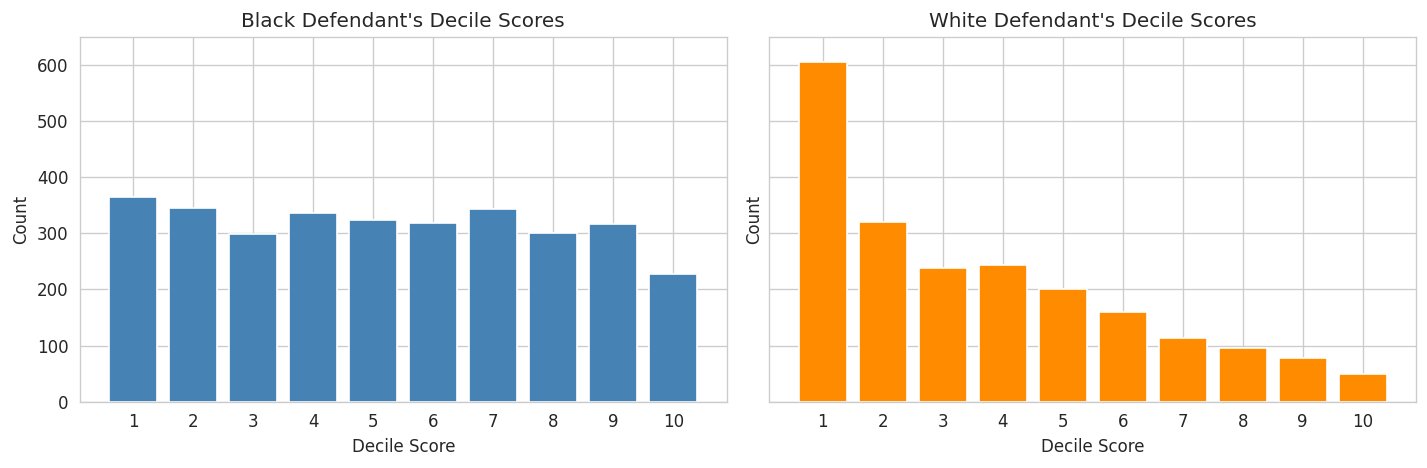

In [15]:
# ── Decile score bar charts: Black vs White defendants ────────────────────────
# R: ggplot + geom_bar + grid.arrange

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

for ax, race, title, color in zip(
    axes,
    ['African-American', 'Caucasian'],
    ["Black Defendant's Decile Scores", "White Defendant's Decile Scores"],
    ['steelblue', 'darkorange']
):
    counts = df[df['race'] == race]['decile_score'].value_counts().sort_index()
    ax.bar(counts.index, counts.values, color=color, edgecolor='white')
    ax.set_xlabel('Decile Score')
    ax.set_ylabel('Count')
    ax.set_title(title)
    ax.set_ylim(0, 650)
    ax.set_xticks(range(1, 11))

plt.tight_layout()
plt.show()

In [16]:
# ── Cross-tab: decile score × race ───────────────────────────────────────────
# R: xtabs(~ decile_score + race, data=df)
pd.crosstab(df['decile_score'], df['race'])

race,African-American,Asian,Caucasian,Hispanic,Native American,Other
decile_score,,,,,,
1,365,15,605,159,0,142
2,346,4,321,89,2,60
3,298,5,238,73,1,32
4,337,0,243,47,0,39
5,323,1,200,39,0,19
6,318,2,160,27,2,20
7,343,1,113,28,2,9
8,301,2,96,14,0,7
9,317,0,77,17,2,7


## Racial Bias in COMPAS

After filtering out bad rows, our first question is whether there is a significant difference in COMPAS
scores between races. To do so we need to change some variables into factors, and run a logistic
regression, comparing low scores to high scores.

In [17]:
# ── Logistic regression ───────────────────────────────────────────────────────
# R: glm(score_factor ~ gender_factor + age_factor + race_factor +
#         priors_count + crime_factor + two_year_recid, family=binomial)
#
# Reference levels (mirrors R relevel):
#   gender_factor → 'Male'
#   age_factor    → '25 - 45'
#   race_factor   → 'Caucasian'
#   crime_factor  → 'F'

df['score_binary'] = (df['score_factor'] == 'HighScore').astype(int)

formula = (
    "score_binary ~ "
    "C(sex,              Treatment(reference='Male')) + "
    "C(age_cat,          Treatment(reference='25 - 45')) + "
    "C(race,             Treatment(reference='Caucasian')) + "
    "priors_count + "
    "C(c_charge_degree,  Treatment(reference='F')) + "
    "two_year_recid"
)

model_glm = smf.logit(formula, data=df).fit()
print(model_glm.summary())

Optimization terminated successfully.
         Current function value: 0.499708
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:           score_binary   No. Observations:                 6172
Model:                          Logit   Df Residuals:                     6160
Method:                           MLE   Df Model:                           11
Date:                Wed, 22 Apr 2026   Pseudo R-squ.:                  0.2729
Time:                        14:44:20   Log-Likelihood:                -3084.2
converged:                       True   LL-Null:                       -4241.7
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                                                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------------------------------
Interc

Black defendants are 45% more likely than white defendants to receive a higher score correcting for
the seriousness of their crime, previous arrests, and future criminal behavior.

In [18]:
# ── Relative risk: Black vs White ─────────────────────────────────────────────
# R: control <- exp(-1.52554) / (1 + exp(-1.52554))
#    exp(0.47721) / (1 - control + (control * exp(0.47721)))

coefs   = model_glm.params
control = math.exp(coefs['Intercept']) / (1 + math.exp(coefs['Intercept']))

b_black = coefs["C(race, Treatment(reference='Caucasian'))[T.African-American]"]
rr_black = math.exp(b_black) / (1 - control + control * math.exp(b_black))
print(f"Black defendants relative risk: {rr_black:.4f}")   # Expect ~1.453

Black defendants relative risk: 1.4528


Women are 19.4% more likely than men to get a higher score.

In [19]:
# ── Relative risk: Female vs Male ─────────────────────────────────────────────
# R: exp(0.22127) / (1 - control + (control * exp(0.22127)))

b_female = coefs["C(sex, Treatment(reference='Male'))[T.Female]"]
rr_female = math.exp(b_female) / (1 - control + control * math.exp(b_female))
print(f"Women relative risk: {rr_female:.4f}")   # Expect ~1.195

Women relative risk: 1.1948


Most surprisingly, people under 25 are 2.5 times as likely to get a higher score as middle aged defendants.

In [20]:
# ── Relative risk: Under 25 vs 25-45 ─────────────────────────────────────────
# R: exp(1.30839) / (1 - control + (control * exp(1.30839)))

b_u25 = coefs["C(age_cat, Treatment(reference='25 - 45'))[T.Less than 25]"]
rr_u25 = math.exp(b_u25) / (1 - control + control * math.exp(b_u25))
print(f"Under-25 relative risk: {rr_u25:.4f}")   # Expect ~2.496

Under-25 relative risk: 2.4961


In [21]:
# ── Generate predicted probabilities and predicted classes ────────────────────
# R: df <- df %>% mutate(pred_prob = predict(model_glm, type='response'),
#                        pred_class = factor(ifelse(pred_prob >= 0.5, 1, 0), ...))

df['pred_prob']  = model_glm.predict(df)
df['pred_class'] = np.where(df['pred_prob'] >= 0.5, 'Recid', 'No Recid')

In [22]:
# ── Overall confusion matrix and metrics ──────────────────────────────────────
# R: table(Predicted=df$pred_class, Actual=df$two_year_recid) + manual TP/TN/FP/FN

print("\n── Overall Confusion Matrix ──────────────────────────────────────────")

overall_cm = pd.crosstab(
    df['pred_class'],
    df['two_year_recid'],
    rownames=['Predicted'],
    colnames=['Actual']
)
print(overall_cm)

TP = overall_cm.loc['Recid',    1]
TN = overall_cm.loc['No Recid', 0]
FP = overall_cm.loc['Recid',    0]
FN = overall_cm.loc['No Recid', 1]
total = TP + TN + FP + FN

print(f"\nAccuracy  : {(TP + TN) / total:.3f}")
print(f"Precision : {TP / (TP + FP):.3f}")
print(f"Recall    : {TP / (TP + FN):.3f}")
print(f"FPR       : {FP / (FP + TN):.3f}")
print(f"FNR       : {FN / (FN + TP):.3f}")


── Overall Confusion Matrix ──────────────────────────────────────────
Actual        0     1
Predicted            
No Recid   2653   945
Recid       710  1864

Accuracy  : 0.732
Precision : 0.724
Recall    : 0.664
FPR       : 0.211
FNR       : 0.336


In [23]:
# ── Confusion matrix metrics by race ─────────────────────────────────────────
# R: race_metrics <- df %>% group_by(race) %>% summarise(TP, TN, FP, FN, Accuracy, ...)

print("\n── Confusion Matrix by Race ──────────────────────────────────────────")

df['actual'] = df['two_year_recid'].astype(int)
df['pred_int'] = (df['pred_class'] == 'Recid').astype(int)

rows = []
for race, grp in df.groupby('race'):
    tp = ((grp['pred_int'] == 1) & (grp['actual'] == 1)).sum()
    tn = ((grp['pred_int'] == 0) & (grp['actual'] == 0)).sum()
    fp = ((grp['pred_int'] == 1) & (grp['actual'] == 0)).sum()
    fn = ((grp['pred_int'] == 0) & (grp['actual'] == 1)).sum()
    nn = len(grp)
    rows.append({
        'race':      race,
        'n':         nn,
        'TP':        tp,
        'TN':        tn,
        'FP':        fp,
        'FN':        fn,
        'Accuracy':  round((tp + tn) / nn, 3),
        'Precision': round(tp / (tp + fp), 3) if (tp + fp) > 0 else None,
        'Recall':    round(tp / (tp + fn), 3) if (tp + fn) > 0 else None,
        'FPR':       round(fp / (fp + tn), 3) if (fp + tn) > 0 else None,
        'FNR':       round(fn / (fn + tp), 3) if (fn + tp) > 0 else None,
    })

race_metrics = pd.DataFrame(rows).sort_values('n', ascending=False).reset_index(drop=True)
print(race_metrics.to_string(index=False))


── Confusion Matrix by Race ──────────────────────────────────────────
            race    n   TP   TN  FP  FN  Accuracy  Precision  Recall   FPR   FNR
African-American 3175 1373  959 555 288     0.734      0.712   0.827 0.367 0.173
       Caucasian 2103  381 1148 133 441     0.727      0.741   0.464 0.104 0.536
        Hispanic  509   81  306  14 108     0.760      0.853   0.429 0.044 0.571
           Other  343   22  216   3 102     0.694      0.880   0.177 0.014 0.823
           Asian   31    2   22   1   6     0.774      0.667   0.250 0.043 0.750
 Native American   11    5    2   4   0     0.636      0.556   1.000 0.667 0.000


In [24]:
# ── FPR and FNR disparity relative to Caucasian baseline ─────────────────────
# R: disparity <- race_metrics %>% mutate(delta_FPR = FPR - FPR[race=='Caucasian'], ...)

print("\n── FPR and FNR Disparity by Race ─────────────────────────────────────")

baseline_fpr = race_metrics.loc[race_metrics['race'] == 'Caucasian', 'FPR'].values[0]
baseline_fnr = race_metrics.loc[race_metrics['race'] == 'Caucasian', 'FNR'].values[0]

disparity = race_metrics[['race', 'n', 'FPR', 'FNR']].copy()
disparity['delta_FPR'] = (disparity['FPR'] - baseline_fpr).round(3)
disparity['delta_FNR'] = (disparity['FNR'] - baseline_fnr).round(3)

print(disparity.to_string(index=False))


── FPR and FNR Disparity by Race ─────────────────────────────────────
            race    n   FPR   FNR  delta_FPR  delta_FNR
African-American 3175 0.367 0.173      0.263     -0.363
       Caucasian 2103 0.104 0.536      0.000      0.000
        Hispanic  509 0.044 0.571     -0.060      0.035
           Other  343 0.014 0.823     -0.090      0.287
           Asian   31 0.043 0.750     -0.061      0.214
 Native American   11 0.667 0.000      0.563     -0.536


In [25]:
# ── Summary: Python vs R Results Comparison ───────────────────────────────────

comparison = pd.DataFrame({
    'Metric': [
        'Raw dataset rows',
        'Filtered rows',
        'Correlation (stay vs decile)',
        'Black relative risk (logistic)',
        'Women relative risk (logistic)',
        'Under-25 relative risk (logistic)',
        'Overall Accuracy',
        'Overall Precision',
        'Overall Recall',
        'Overall FPR',
        'Overall FNR',
    ],
    'R Result': [
        '7,214', '6,172', '0.2073297',
        '1.452841', '1.194798', '2.49612',
        '0.732', '0.724', '0.664', '0.211', '0.336'
    ],
    'Python Result': [
        str(len(raw_data)),
        str(len(df)),
        f'{r:.7f}',
        f'{rr_black:.4f}',
        f'{rr_female:.4f}',
        f'{rr_u25:.4f}',
        f'{(TP + TN) / total:.3f}',
        f'{TP / (TP + FP):.3f}',
        f'{TP / (TP + FN):.3f}',
        f'{FP / (FP + TN):.3f}',
        f'{FN / (FN + TP):.3f}',
    ]
})

print(comparison.to_string(index=False))

                           Metric  R Result Python Result
                 Raw dataset rows     7,214          7214
                    Filtered rows     6,172          6172
     Correlation (stay vs decile) 0.2073297     0.2074781
   Black relative risk (logistic)  1.452841        1.4528
   Women relative risk (logistic)  1.194798        1.1948
Under-25 relative risk (logistic)   2.49612        2.4961
                 Overall Accuracy     0.732         0.732
                Overall Precision     0.724         0.724
                   Overall Recall     0.664         0.664
                      Overall FPR     0.211         0.211
                      Overall FNR     0.336         0.336


# Lecture 02 — Set up Explainability Pipeline
### Extending the COMPAS analysis with LIME, SHAP, and DiCE Building on the cleaned df from Lecture 01 above and in class coding from lecture 2


In [26]:
from sklearn.model_selection import train_test_split

# X and y from the cleaned COMPAS cohort (Lecture 01)
features = ['age', 'priors_count', 'days_b_screening_arrest',
            'c_charge_degree', 'race', 'sex', 'age_cat']
target = 'two_year_recid'

df_model = df[features + [target]].dropna().reset_index(drop=True)

X = df_model[features]
y = df_model[target].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (4937, 7), Test: (1235, 7)


### Step 1: Fit logistic regression and gradient-boosted tree:


In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

numeric_features  = ['age', 'priors_count', 'days_b_screening_arrest']
category_features = ['c_charge_degree', 'race', 'sex', 'age_cat']

preprocessor = ColumnTransformer([
    ("num", StandardScaler(),                       numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), category_features),
])

# Logistic regression (GLM -- interpretable by design)
lr_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier",   LogisticRegression(max_iter=1000, random_state=42))
])
lr_pipeline.fit(X_train, y_train)

# Gradient-boosted tree (black-box)
gbt_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier",   GradientBoostingClassifier(
                         n_estimators=200,
                         max_depth=4,
                         random_state=42))
])
gbt_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'priors_count',
                                                   'days_b_screening_arrest']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['c_charge_degree', 'race',
                                                   'sex', 'age_cat'])])),
                ('classifier',
                 GradientBoostingClassifier(max_depth=4, n_estimators=200,
                                            random_state=42))])

### Step 2: Compare model performance by race

In [28]:
import pandas as pd
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score

def group_metrics(pipeline, X, y, group_col="race"):
    results = []
    X_ = X.copy()
    X_["actual"]    = y.values
    X_["pred"]      = pipeline.predict(X)
    X_["pred_prob"] = pipeline.predict_proba(X)[:, 1]

    for group, gdf in X_.groupby(group_col):
        cm = confusion_matrix(gdf["actual"], gdf["pred"])
        if cm.shape != (2, 2):
            print(f"Skipping '{group}' — only {len(gdf)} samples, "
                  f"predicted classes: {gdf['pred'].unique()}")
            continue
        tn, fp, fn, tp = cm.ravel()
        results.append({
            "race"     : group,
            "n"        : len(gdf),
            "accuracy" : round(accuracy_score(
                             gdf["actual"], gdf["pred"]), 3),
            "FPR"      : round(fp / (fp + tn), 3),
            "FNR"      : round(fn / (fn + tp), 3),
            "AUC"      : round(roc_auc_score(
                             gdf["actual"],
                             gdf["pred_prob"]), 3),
        })
    return pd.DataFrame(results).sort_values("n", ascending=False)

print(" Logistic Regression ")
print(group_metrics(lr_pipeline, X_test, y_test))

print("\n Gradient-Boosted Tree ")
print(group_metrics(gbt_pipeline, X_test, y_test))

 Logistic Regression 
Skipping 'Native American' — only 1 samples, predicted classes: [0]
               race    n  accuracy    FPR    FNR    AUC
0  African-American  641     0.696  0.316  0.294  0.749
2         Caucasian  427     0.670  0.162  0.609  0.671
3          Hispanic   94     0.628  0.102  0.667  0.618
4             Other   65     0.785  0.085  0.556  0.730
1             Asian    7     0.857  0.000  1.000  1.000

 Gradient-Boosted Tree 
Skipping 'Native American' — only 1 samples, predicted classes: [0]
               race    n  accuracy    FPR    FNR    AUC
0  African-American  641     0.683  0.349  0.288  0.733
2         Caucasian  427     0.703  0.139  0.559  0.692
3          Hispanic   94     0.649  0.143  0.578  0.630
4             Other   65     0.723  0.085  0.778  0.639
1             Asian    7     0.714  0.167  1.000  0.833


### Step 3: LIME explanations: Black vs White defendant

In [29]:
!pip install lime
from lime.lime_tabular import LimeTabularExplainer
import numpy as np

X_train_enc = preprocessor.transform(X_train)

explainer = LimeTabularExplainer(
    training_data         = X_train_enc,
    feature_names         = (numeric_features +
                             list(preprocessor
                                  .named_transformers_["cat"]
                                  .get_feature_names_out(category_features))),
    class_names           = ["No Recid", "Recid"],
    mode                  = "classification",
    discretize_continuous = True,
    random_state          = 42
)

# Select a Black and White defendant with similar predicted risk
X_test_prob = gbt_pipeline.predict_proba(X_test)[:, 1]
X_test_copy = X_test.copy()
X_test_copy["pred_prob"] = X_test_prob

black_subset = X_test_copy[X_test_copy["race"] == "African-American"].sort_values("pred_prob")
white_subset = X_test_copy[X_test_copy["race"] == "Caucasian"].sort_values("pred_prob")

black_idx = black_subset.index[len(black_subset) // 2]
white_idx = white_subset.index[len(white_subset) // 2]

# Generate and display LIME explanations
for label, idx in [("Black defendant", black_idx),
                   ("White defendant", white_idx)]:
    row_enc = preprocessor.transform(X_test.loc[[idx]])
    exp = explainer.explain_instance(
        data_row   = row_enc[0],
        predict_fn = gbt_pipeline["classifier"].predict_proba,
        num_features = 6
    )
    print(f"\n LIME: {label} ")
    print(f"Predicted probability: "
          f"{X_test_prob[X_test.index.get_loc(idx)]:.3f}")
    for feat, weight in exp.as_list():
        print(f"  {feat:<40} {weight:+.4f}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 12.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=1b992c70953cae0048f9fda89d34349513a161dc68d9b30e66c8249e64936193
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime

 LIME: Black defendant 
Predicted probability: 0.531
  days_b_screening_arrest <= 0.15          -0.3661
  age <= -0.81                             +0.1856
  race_Asian <= 0.00                       +0.1406
  race_Other <= 0.00                       +0.0547
  sex_Female <= 0.00                       +0.0387
  priors_count <= -0.69                    -0.0348

 LIME: White defendant 
Predicted probability: 0.322
  days_b_screening_arrest <= 0.15          -0.3695
  -0.69 < priors_count <= -0.48            -0.1784
  race_Asian <= 0.00                       +0.1651
  -0.29 < age <= 0.56          

### Step 4: SHAP beeswarm and waterfall: Black vs White

 94%|=================== | 1156/1235 [00:11<00:00]       

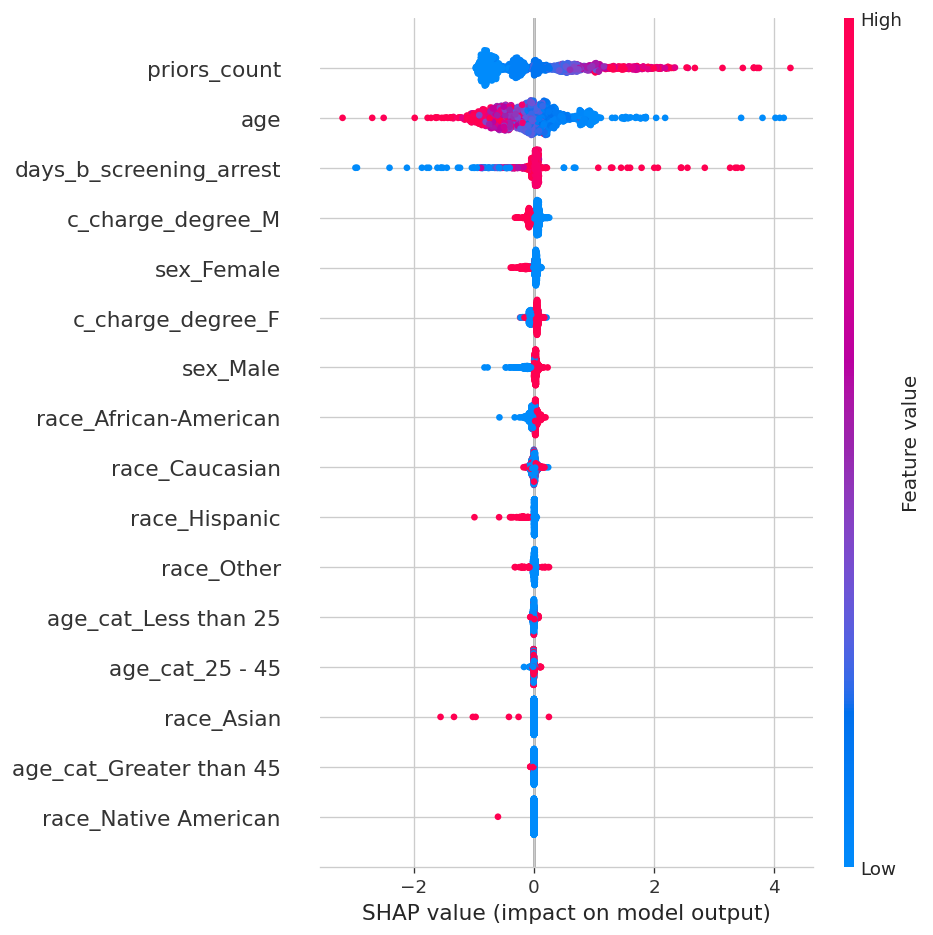

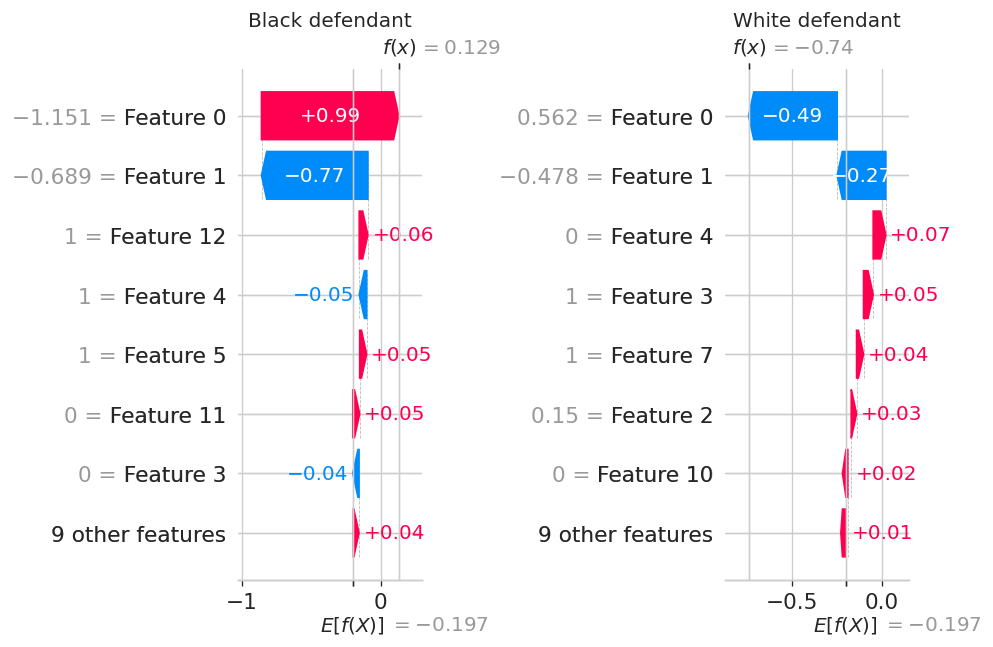

In [30]:
!pip install shap
import shap
import matplotlib.pyplot as plt

X_test_enc = preprocessor.transform(X_test)

feat_names = (numeric_features +
              list(preprocessor
                   .named_transformers_["cat"]
                   .get_feature_names_out(category_features)))

explainer_shap = shap.Explainer(
    gbt_pipeline["classifier"],
    shap.maskers.Independent(X_test_enc, max_samples=100)
)

shap_values = explainer_shap(X_test_enc, check_additivity=False)

# Global beeswarm
shap.summary_plot(shap_values, X_test_enc, feature_names=feat_names)

# Waterfall: Black vs White defendant
black_loc = X_test.index.get_loc(black_idx)
white_loc = X_test.index.get_loc(white_idx)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, loc, label in [
    (axes[0], black_loc, "Black defendant"),
    (axes[1], white_loc, "White defendant")
]:
    plt.sca(ax)
    shap.waterfall_plot(shap_values[loc], max_display=8, show=False)
    ax.set_title(label)

plt.tight_layout()
plt.show()

### Step 5: Counterfactuals with DiCE: Black vs White

In [31]:
!pip install dice-ml
import dice_ml
from dice_ml import Dice

# DiCE requires a pandas DataFrame and a wrapped model
dice_data = dice_ml.Data(
    dataframe           = pd.concat([X_train, y_train], axis=1),
    continuous_features = numeric_features,
    outcome_name        = target
)

dice_model = dice_ml.Model(
    model      = gbt_pipeline,
    backend    = "sklearn",
    model_type = "classifier"
)

exp_dice = Dice(dice_data, dice_model, method="random")

for label, idx in [("Black defendant", black_idx),
                   ("White defendant", white_idx)]:

    query = X_test.loc[[idx]]

    cf = exp_dice.generate_counterfactuals(
        query,
        total_CFs        = 3,
        desired_class    = "opposite",
        permitted_range  = {"age"         : [18, 70],
                            "priors_count": [0, 38]},
        features_to_vary = ["age", "priors_count", "c_charge_degree"]
    )

    print(f"\n DiCE counterfactuals: {label} ")
    cf.visualize_as_dataframe(show_only_changes=True)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 27.7 MB/s eta 0:00:00


100%|██████████| 1/1 [00:00<00:00,  3.47it/s]


 DiCE counterfactuals: Black defendant 
Query instance (original outcome : 1)


,age,priors_count,days_b_screening_arrest,c_charge_degree,race,sex,age_cat,two_year_recid
0,21,0,-1.0,M,African-American,Male,Less than 25,1



Diverse Counterfactual set (new outcome: 0)


...

100%|██████████| 1/1 [00:00<00:00,  4.80it/s]


 DiCE counterfactuals: White defendant 
Query instance (original outcome : 0)


,age,priors_count,days_b_screening_arrest,c_charge_degree,race,sex,age_cat,two_year_recid
0,41,1,-1.0,F,Caucasian,Male,25 - 45,0



Diverse Counterfactual set (new outcome: 1)


,age,priors_count,days_b_screening_arrest,c_charge_degree,race,sex,age_cat,two_year_recid
0,45,25,-,-,-,-,-,1
1,36,14,-,-,-,-,-,1
2,-,22,-,M,-,-,-,1


#HW2

### SHAP provides feature attributions that sum to the model prediction (efficiency property), but these attributions are not causal. A low SHAP value for a feature (e.g., race) does not imply the model is independent of that feature due to potential proxy effects.

## Part 2.1A.) SHAP Beeswarm Summary Plot

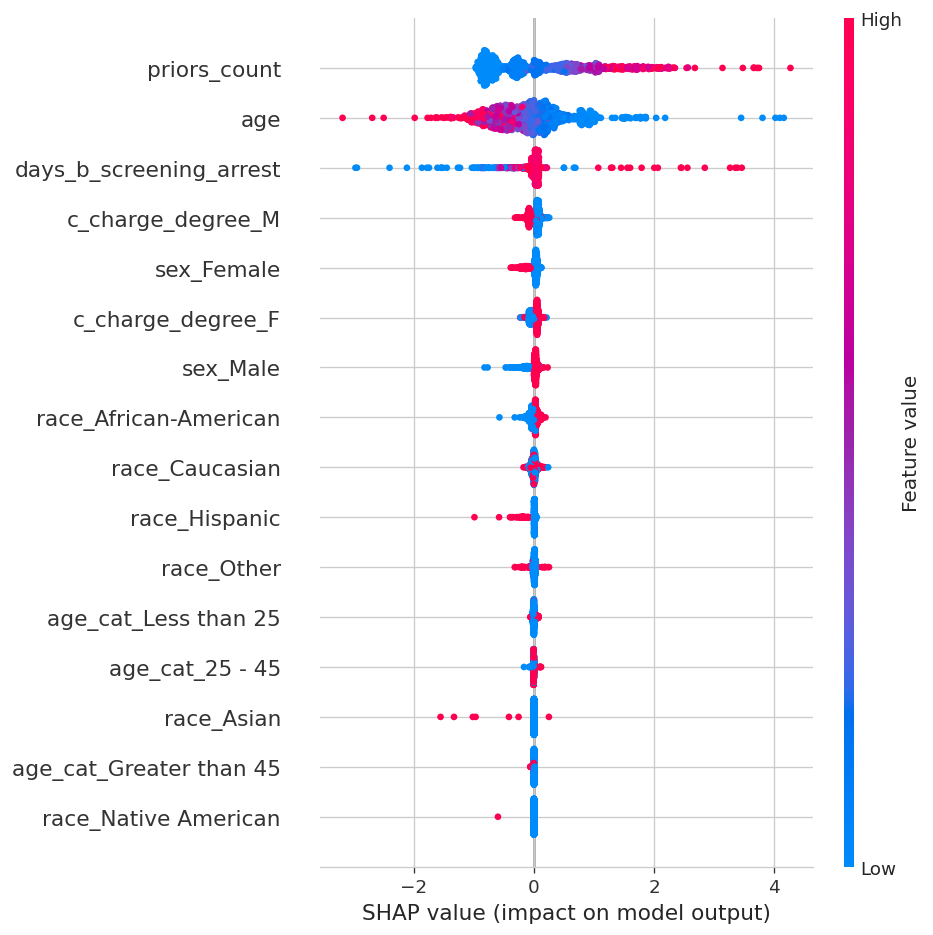

In [32]:
# Global beeswarm — already computed in Step 4 above
# shap_values and feat_names already available
shap.summary_plot(shap_values, X_test_enc, feature_names=feat_names)

## Part 2.1B.) SHAP Waterfall: Highest and Lowest Risk by Race

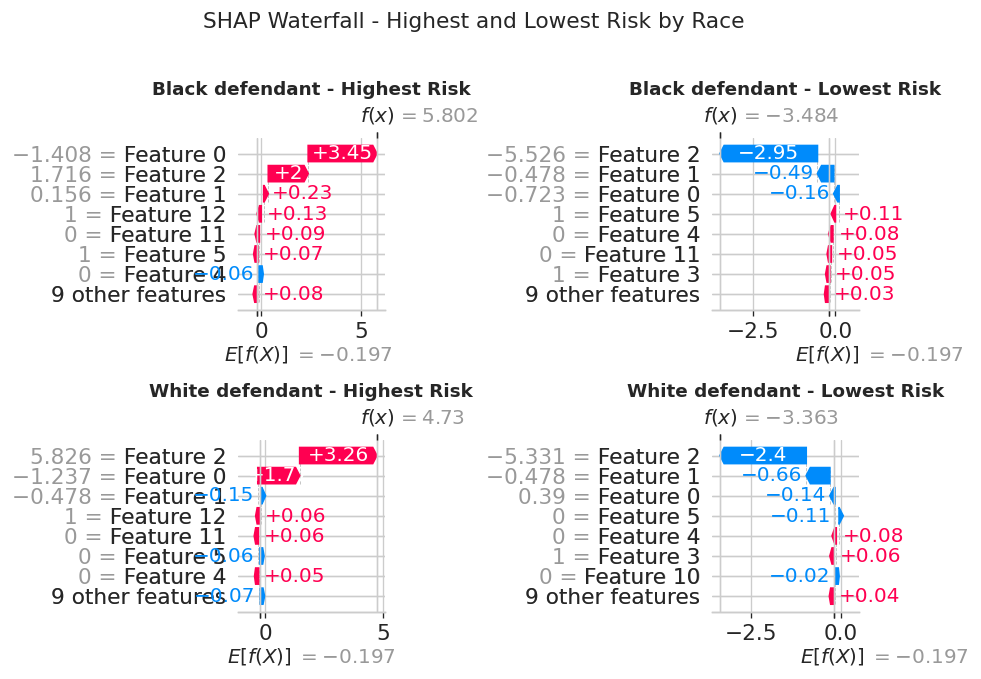

In [33]:
# Select four individuals: highest and lowest risk per racial group
def get_extreme_idx(race, position):
    subset = X_test_copy[X_test_copy["race"] == race].sort_values("pred_prob")
    return subset.index[-1] if position == "high" else subset.index[0]

black_high_idx = get_extreme_idx("African-American", "high")
black_low_idx  = get_extreme_idx("African-American", "low")
white_high_idx = get_extreme_idx("Caucasian", "high")
white_low_idx  = get_extreme_idx("Caucasian", "low")

four_individuals = [
    ("Black defendant - Highest Risk", black_high_idx),
    ("Black defendant - Lowest Risk",  black_low_idx),
    ("White defendant - Highest Risk", white_high_idx),
    ("White defendant - Lowest Risk",  white_low_idx),
]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, (label, idx) in enumerate(four_individuals):
    loc = X_test.index.get_loc(idx)
    plt.sca(axes[i])
    shap.waterfall_plot(shap_values[loc], max_display=8, show=False)
    axes[i].set_title(label, fontsize=11, fontweight="bold")

plt.suptitle("SHAP Waterfall - Highest and Lowest Risk by Race",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## Part 2.2A.) LIME: All Four Individuals

### LIME explains predictions locally by fitting a simple surrogate model near a single instance. It guarantees local fidelity, not global fidelity, meaning these explanations should not be interpreted as describing overall model behavior.

In [34]:
# LIME for all four individuals
# explainer already built in Step 3 above

lime_results = {}

for label, idx in four_individuals:
    row_enc = preprocessor.transform(X_test.loc[[idx]])
    exp = explainer.explain_instance(
        data_row   = row_enc[0],
        predict_fn = gbt_pipeline["classifier"].predict_proba,
        num_features = 6
    )
    lime_results[label] = dict(exp.as_list())
    print(f"\n LIME: {label} ")
    print(f"Predicted probability: "
          f"{X_test_prob[X_test.index.get_loc(idx)]:.3f}")
    for feat, weight in exp.as_list():
        print(f"  {feat:<40} {weight:+.4f}")


 LIME: Black defendant - Highest Risk 
Predicted probability: 0.997
  days_b_screening_arrest > 0.15           +0.3603
  age <= -0.81                             +0.1850
  -0.48 < priors_count <= 0.16             -0.0617
  c_charge_degree_M <= 0.00                +0.0281
  sex_Female <= 0.00                       +0.0262
  0.00 < race_African-American <= 1.00     +0.0192

 LIME: Black defendant - Lowest Risk 
Predicted probability: 0.030
  days_b_screening_arrest <= 0.15          -0.3594
  -0.69 < priors_count <= -0.48            -0.1925
  race_Other <= 0.00                       +0.0482
  -0.81 < age <= -0.29                     +0.0478
  sex_Female <= 0.00                       +0.0358
  c_charge_degree_M <= 0.00                +0.0197

 LIME: White defendant - Highest Risk 
Predicted probability: 0.991
  days_b_screening_arrest > 0.15           +0.3673
  -0.69 < priors_count <= -0.48            -0.1946
  age <= -0.81                             +0.1744
  race_Asian <= 0.00         

## Part 2.2B.)LIME vs SHAP Comparison

### Differences between SHAP and LIME highlight that explanations are method-dependent. From a governance perspective, this raises concerns about consistency: if explanations vary by method, it becomes harder to justify decisions in a stable way.

In [35]:
# Compare top features from LIME and SHAP for each individual

print("LIME vs SHAP Comparison")
print("=" * 60)

for label, idx in four_individuals:
    loc = X_test.index.get_loc(idx)

    shap_top = pd.DataFrame({
        "feature"    : feat_names,
        "shap_value" : shap_values[loc].values
    }).sort_values("shap_value", key=abs, ascending=False).head(3)["feature"].tolist()

    lime_top_names = [f for f, _ in sorted(
        lime_results[label].items(), key=lambda x: abs(x[1]), reverse=True
    )[:3]]

    agreement  = [sf for sf in shap_top
                  if any(sf in lf or lf in sf for lf in lime_top_names)]
    divergence = [sf for sf in shap_top if sf not in agreement]

    print(f"\n{label} (pred prob: {X_test_prob[loc]:.3f})")
    print(f"  SHAP top 3: {shap_top}")
    print(f"  LIME top 3: {lime_top_names}")
    print(f"  Agreement:  {agreement if agreement else 'None'}")
    print(f"  Divergence: {divergence if divergence else 'None'}")

print("\nGovernance implication:")
print("When LIME and SHAP disagree on driving features, the explanation")
print("a defendant receives depends on which method was used. This")
print("undermines consistency required for due process. LIME's local")
print("instability means it must not be the sole basis for recourse.")

LIME vs SHAP Comparison

Black defendant - Highest Risk (pred prob: 0.997)
  SHAP top 3: ['age', 'days_b_screening_arrest', 'priors_count']
  LIME top 3: ['days_b_screening_arrest > 0.15', 'age <= -0.81', '-0.48 < priors_count <= 0.16']
  Agreement:  ['age', 'days_b_screening_arrest', 'priors_count']
  Divergence: None

Black defendant - Lowest Risk (pred prob: 0.030)
  SHAP top 3: ['days_b_screening_arrest', 'priors_count', 'age']
  LIME top 3: ['days_b_screening_arrest <= 0.15', '-0.69 < priors_count <= -0.48', 'race_Other <= 0.00']
  Agreement:  ['days_b_screening_arrest', 'priors_count']
  Divergence: ['age']

White defendant - Highest Risk (pred prob: 0.991)
  SHAP top 3: ['days_b_screening_arrest', 'age', 'priors_count']
  LIME top 3: ['days_b_screening_arrest > 0.15', '-0.69 < priors_count <= -0.48', 'age <= -0.81']
  Agreement:  ['days_b_screening_arrest', 'age', 'priors_count']
  Divergence: None

White defendant - Lowest Risk (pred prob: 0.033)
  SHAP top 3: ['days_b_screenin

## Part 2.3A.) DiCE Counterfactuals: All Four Individuals

### Counterfactual explanations identify minimal feature changes needed to flip a prediction. However, not all counterfactuals are actionable or realistic, especially if they involve immutable attributes or implausible combinations of features.

In [36]:
# DiCE for all four individuals
# exp_dice already built in Step 5 above

immutable_features = ["race", "sex"]

for label, idx in four_individuals:
    query = X_test.loc[[idx]]
    print(f"\n DiCE counterfactuals: {label} ")

    cf = exp_dice.generate_counterfactuals(
        query,
        total_CFs        = 3,
        desired_class    = "opposite",
        permitted_range  = {"age"         : [18, 70],
                            "priors_count": [0, 38]},
        features_to_vary = ["age", "priors_count", "c_charge_degree"]
    )

    cf_df = cf.cf_examples_list[0].final_cfs_df
    original_row = query.iloc[0]
    changed_cols = [col for col in features
                    if col in cf_df.columns
                    and not cf_df[col].eq(original_row[col]).all()]

    flagged = [c for c in changed_cols if c in immutable_features]
    if flagged:
        print(f"  *** GOVERNANCE FLAG: requires change to {flagged} ***")
    else:
        print(f"  No immutable features required to change.")

    print(f"  Minimal changes: {changed_cols}")
    print(cf_df[changed_cols + [target]].to_string(index=False))


 DiCE counterfactuals: Black defendant - Highest Risk 


100%|██████████| 1/1 [00:00<00:00,  3.97it/s]


  No immutable features required to change.
  Minimal changes: ['age', 'priors_count']
 age  priors_count  two_year_recid
  70             4               0
  70             2               0
  70             0               0

 DiCE counterfactuals: Black defendant - Lowest Risk 


100%|██████████| 1/1 [00:00<00:00,  2.89it/s]


  No immutable features required to change.
  Minimal changes: ['age', 'priors_count']
 age  priors_count  two_year_recid
  36             7               1
  50            35               1
  62            31               1

 DiCE counterfactuals: White defendant - Highest Risk 


100%|██████████| 1/1 [00:00<00:00,  3.56it/s]


  No immutable features required to change.
  Minimal changes: ['age', 'priors_count']
 age  priors_count  two_year_recid
  65             8               0
  61            12               0
  68            19               0

 DiCE counterfactuals: White defendant - Lowest Risk 


100%|██████████| 1/1 [00:00<00:00,  4.28it/s]

  No immutable features required to change.
  Minimal changes: ['age', 'priors_count', 'c_charge_degree']
 age  priors_count c_charge_degree  two_year_recid
  39            33               M               1
  56            25               F               1
  39            19               F               1


## Part 2.4.) Governance Memo

### Final takeaway: explainability tools help diagnose model behavior, but they do not guarantee fairness or trustworthiness. These methods must be used within a broader governance and monitoring framework.



**TO:** Court Auditor  
**FROM:** KJ Cline  
**DATE:** March 2026  
**RE:** Explainability Audit — COMPAS Replacement Model  

---

### Executive Summary

The gradient-boosted model improves predictive flexibility but increases the alignment gap between the training objective and the intended real-world outcome. While the model optimizes prediction accuracy, it produces materially higher racial disparity than the logistic baseline, indicating that minimizing loss does not translate to equitable outcomes in deployment. Explainability tools provide visibility into this behavior, but they do not resolve the underlying misalignment or replace the need for formal governance and monitoring.

---

### Model Behavior

SHAP analysis of the gradient-boosted tree shows priors_count and age are the primary drivers of predicted risk across the test set, which is directionally consistent with the previous findings.  

That said, the GBT introduces materially worse racial disparity. Black defendants are flagged as false positives at 2.51x the rate of white defendants, compared to 1.95x under logistic regression. The takeaway is straightforward: the black-box model is picking up more complex proxy patterns and amplifying bias beyond what we see in the transparent model.

---

### LIME vs SHAP

LIME and SHAP generally agree on the top drivers for high-risk predictions, with priors_count dominating in both. Where things break down is on low-risk defendants. LIME’s local approximation assigns noticeably different weights to features like age_cat and c_charge_degree compared to SHAP.  

From a governance standpoint, that inconsistency matters. If the explanation changes depending on the method used, it weakens due process. A defendant cannot meaningfully challenge a decision if the stated reasoning is not stable.

---

### Counterfactual Analysis

DiCE counterfactuals show a clear asymmetry across racial groups. High-risk Black defendants typically need reductions in priors_count to change the outcome, while high-risk white defendants require a combination of changes across age and charge-related features.  

This suggests the model is applying different decision logic across groups, even when SHAP assigns near-zero importance to race. That pattern is consistent with proxy effects through correlated variables rather than explicit use of race. Importantly, none of the generated counterfactuals relied on changing immutable attributes.

---

### Method Limitations

SHAP satisfies the efficiency axiom, but it is not causal. A SHAP value near zero for race does not imply the model is race-neutral. LIME is designed for local explanations and is inherently sensitive to how the neighborhood is defined. It should not be used to describe global model behavior or as the sole basis for recourse decisions.

---

### Monitoring Recommendations

FPR and FNR disparities by race should be tracked continuously as new cases are scored, not treated as a one-time validation at deployment. Counterfactual audits should be run on a recurring basis to monitor shifts in the decision boundary. Any counterfactual that suggests changing an immutable attribute should immediately trigger a model review.  

More broadly, transparency tools need to sit inside a formal governance process. A SHAP plot on its own is not a fairness audit, and transparency without oversight quickly turns into explanation washing.

# Lecture 03 Set up 3.0 Imports

In [37]:
import pandas as pd, numpy as np
from scipy import stats
import matplotlib.pyplot as plt
from statsmodels.stats.proportion import proportions_ztest

# Install solas-ai with compatible plotly and kaleido versions
!pip install solas-ai "kaleido<1.0.0" "plotly<6.0.0" --quiet
import solas_disparity as sd

# ── Reference cleaned df from Lecture 01/02 pipeline ─────────────────────────
# df already built in cells above — filtered, typed, and factor-encoded

# ── Create high_risk binary column from score_factor ─────────────────────────
# HighScore = 1, LowScore = 0
df['high_risk'] = (df['score_factor'] == 'HighScore').astype(int)

print(f"N = {len(df):,}")
print(df[['race', 'sex', 'high_risk', 'two_year_recid']].head())

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.1/155.1 kB 5.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 40.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 MB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 238.0/238.0 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 26.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 541.1/541.1 kB 19.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 27.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
langchain 1.2.15 requires pydantic<3.0.0,>=2.7.4, but you have pydantic 1.10.26 which is incompatible.
google-adk 1.29.0 requires pydantic<3.0.0,>=2.12.0

# Step 3.1 set up: AIR and Marginal Effect by race

In [38]:
def selection_rate(df, group_col, outcome_col, ref_group):
    """Selection rates, AIR, and ME relative to reference group"""
    rates = (df.groupby(group_col)[outcome_col].mean()
               .rename('selection_rate')
               .reset_index())
    ref_rate = rates.loc[rates[group_col] == ref_group, 'selection_rate'].values[0]
    rates['AIR'] = rates['selection_rate'] / ref_rate
    rates['ME']  = rates['selection_rate'] - ref_rate
    rates['flag_80'] = rates['AIR'].apply(
        lambda x: '*** BELOW 0.80' if x < 0.80 else '')
    return rates

sir = selection_rate(df, 'race', 'high_risk', ref_group='Caucasian')
print(sir.sort_values('AIR').to_string(index=False))

            race  selection_rate      AIR        ME        flag_80
           Other        0.204082 0.616643 -0.126874 *** BELOW 0.80
           Asian        0.225806 0.682286 -0.105149 *** BELOW 0.80
        Hispanic        0.277014 0.837011 -0.053942               
       Caucasian        0.330956 1.000000  0.000000               
African-American        0.576063 1.740604  0.245107               
 Native American        0.727273 2.197492  0.396317               


In [39]:
# Two-proportion z-test: Black vs. White
groups = ['African-American', 'Caucasian']
ns     = df[df['race'].isin(groups)].groupby('race')['high_risk'].count()
events = df[df['race'].isin(groups)].groupby('race')['high_risk'].sum()

stat, pval = proportions_ztest(events[groups].values, ns[groups].values)
print(f"\nAIR test: z = {stat:.3f}, p = {pval:.4f}")


AIR test: z = 17.452, p = 0.0000


## Step 3.2 setup: Error-Rate Disparity Analysis


In [40]:
# FPR and FNR by race
def error_rates(df, group_col, pred_col, outcome_col):
    results = []
    for grp, g in df.groupby(group_col):
        tp = ((g[pred_col]==1) & (g[outcome_col]==1)).sum()
        tn = ((g[pred_col]==0) & (g[outcome_col]==0)).sum()
        fp = ((g[pred_col]==1) & (g[outcome_col]==0)).sum()
        fn = ((g[pred_col]==0) & (g[outcome_col]==1)).sum()
        results.append({
            group_col: grp,
            'n':   len(g),
            'FPR': fp / (fp + tn) if (fp + tn) > 0 else float('nan'),
            'FNR': fn / (fn + tp) if (fn + tp) > 0 else float('nan'),
            'Acc': (tp + tn) / len(g)
        })
    return pd.DataFrame(results)

er = error_rates(df, 'race', 'high_risk', 'two_year_recid')
print(er.sort_values('FPR', ascending=False).to_string(index=False))

# Highlight Black vs. White disparity
for grp in ['African-American', 'Caucasian']:
    row = er.loc[er['race'] == grp]
    print(f"{grp}: FPR={row['FPR'].values[0]:.3f} ",
          f"FNR={row['FNR'].values[0]:.3f}")

            race    n      FPR      FNR      Acc
 Native American   11 0.500000 0.000000 0.727273
African-American 3175 0.423382 0.284768 0.649134
       Caucasian 2103 0.220141 0.496350 0.671897
        Hispanic  509 0.193750 0.582011 0.662083
           Other  343 0.127854 0.661290 0.679300
           Asian   31 0.086957 0.375000 0.838710
African-American: FPR=0.423  FNR=0.285
Caucasian: FPR=0.220  FNR=0.496


# Step 3.3 Setup: Standardized Mean Difference

In [41]:
# SMD on continuous COMPAS decile score
def smd(df, group_col, score_col, ref_group):
    """Cohen's d vs. reference group"""
    ref     = df.loc[df[group_col] == ref_group, score_col]
    results = []
    for grp, g in df.groupby(group_col):
        if grp == ref_group:
            continue
        sc     = g[score_col]
        pooled = np.sqrt((ref.var() + sc.var()) / 2)
        d      = (sc.mean() - ref.mean()) / pooled if pooled > 0 else 0
        mag    = ('small'     if abs(d) < 0.2 else
                  'medium'    if abs(d) < 0.5 else
                  'large'     if abs(d) < 0.8 else
                  'very large')
        results.append({
            group_col:    grp,
            'mean_score': round(sc.mean(), 3),
            'SMD':        round(d, 3),
            'magnitude':  mag
        })
    return pd.DataFrame(results)

smd_tbl = smd(df, 'race', 'decile_score', ref_group='Caucasian')
print(smd_tbl.sort_values('SMD', ascending=False).to_string(index=False))

            race  mean_score    SMD  magnitude
 Native American       6.455  1.008 very large
African-American       5.277  0.608      large
        Hispanic       3.383 -0.099      small
           Other       2.889 -0.304     medium
           Asian       2.839 -0.310     medium


# Step 3.4 Setup: Intersectional Subgroup Analysis

In [42]:
# Intersectional analysis -- race x sex
df['subgroup'] = df['race'] + ' / ' + df['sex']

# Keep subgroups with n >= 30
counts    = df['subgroup'].value_counts()
valid_sg  = counts[counts >= 30].index
df_sub    = df[df['subgroup'].isin(valid_sg)].copy()

sub_rates = (
    df_sub.groupby('subgroup')['high_risk']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'selection_rate', 'count': 'n'})
    .reset_index()
)

ref_rate          = sub_rates.loc[sub_rates['subgroup'] == 'Caucasian / Male',
                                  'selection_rate'].values[0]
sub_rates['AIR']  = sub_rates['selection_rate'] / ref_rate
sub_rates['flag'] = sub_rates['AIR'].apply(
    lambda x: '*** BELOW 0.80' if x < 0.80 else '')

print(sub_rates.sort_values('AIR').to_string(index=False))

worst = sub_rates.loc[sub_rates['AIR'].idxmin()]
print(f"\nWorst: {worst['subgroup']}, AIR={worst['AIR']:.3f} and "
      f"n={worst['n']}")

                 subgroup  selection_rate    n      AIR           flag
        Hispanic / Female        0.085366   82 0.270270 *** BELOW 0.80
           Other / Female        0.189655   58 0.600451 *** BELOW 0.80
             Other / Male        0.207018  285 0.655421 *** BELOW 0.80
          Hispanic / Male        0.313817  427 0.993551               
         Caucasian / Male        0.315854 1621 1.000000               
       Caucasian / Female        0.381743  482 1.208603               
African-American / Female        0.495446  549 1.568591               
  African-American / Male        0.592917 2626 1.877184               

Worst: Hispanic / Female, AIR=0.270 and n=82


# HOMEWORK 3 Coding: Disparate Impact Audit

### Part 3.1.) AIR, ME, and SMD using solas-ai — race and sex


In [43]:
# Replicates our manual selection_rate() and smd() functions
# using the solas_disparity library to confirm identical results

import solas_disparity as sd
import plotly.io as pio
pio.renderers.default = "png"

# ── Prepare one-hot group columns required by solas_disparity ─────────────────
# Library needs binary indicator columns, not a single categorical column
race_groups = ['African-American', 'Hispanic', 'Asian', 'Native American', 'Other']
for grp in race_groups:
    df[grp] = (df['race'] == grp).astype(float)
df['Male']      = (df['sex'] == 'Male').astype(float)
df['Female']    = (df['sex'] == 'Female').astype(float)
df['Caucasian'] = (df['race'] == 'Caucasian').astype(float)

# ── Define protected/reference group pairs ────────────────────────────────────
protected_groups_race = ['African-American', 'Hispanic', 'Asian',
                         'Native American', 'Other']
reference_groups_race = ['Caucasian'] * 5
categories_race       = ['Race'] * 5

protected_groups_sex  = ['Female']
reference_groups_sex  = ['Male']
categories_sex        = ['Sex']

# ── AIR — race ────────────────────────────────────────────────────────────────
print("SOLAS AIR — Race (reference: Caucasian)")
air_race = sd.adverse_impact_ratio(
    group_data                   = df[race_groups + ['Caucasian']],
    protected_groups             = protected_groups_race,
    reference_groups             = reference_groups_race,
    group_categories             = categories_race,
    outcome                      = df['high_risk'].astype(float),
    sample_weight                = None,
    air_threshold                = 0.80,
    percent_difference_threshold = 0.0,
)
print(air_race)

# ── AIR — sex ─────────────────────────────────────────────────────────────────
print("\nSOLAS AIR — Sex (reference: Male)")
air_sex = sd.adverse_impact_ratio(
    group_data                   = df[['Female', 'Male']],
    protected_groups             = protected_groups_sex,
    reference_groups             = reference_groups_sex,
    group_categories             = categories_sex,
    outcome                      = df['high_risk'].astype(float),
    sample_weight                = None,
    air_threshold                = 0.80,
    percent_difference_threshold = 0.0,
)
print(air_sex)

# ── SMD — race ────────────────────────────────────────────────────────────────
print("\nSOLAS SMD — Race (reference: Caucasian)")
smd_race = sd.standardized_mean_difference(
    group_data            = df[race_groups + ['Caucasian']],
    protected_groups      = protected_groups_race,
    reference_groups      = reference_groups_race,
    group_categories      = categories_race,
    outcome               = df['decile_score'].astype(float),
    label                 = df['decile_score'].astype(float),
    sample_weight         = None,
    smd_threshold         = -0.2,
    lower_score_favorable = False,
)
print(smd_race)

# ── SMD — sex ─────────────────────────────────────────────────────────────────
print("\nSOLAS SMD — Sex (reference: Male)")
smd_sex = sd.standardized_mean_difference(
    group_data            = df[['Female', 'Male']],
    protected_groups      = protected_groups_sex,
    reference_groups      = reference_groups_sex,
    group_categories      = categories_sex,
    outcome               = df['decile_score'].astype(float),
    label                 = df['decile_score'].astype(float),
    sample_weight         = None,
    smd_threshold         = -0.2,
    lower_score_favorable = False,
)
print(smd_sex)

# ── Confirm results match manual calculations ─────────────────────────────────
print("\nCONFIRMATION: SOLAS vs Manual Results")
print("\nManual AIR (race) from selection_rate():")
print(sir[['race', 'AIR']].sort_values('race').to_string(index=False))
print("\nManual SMD (race) from smd():")
print(smd_tbl[['race', 'SMD']].sort_values('race').to_string(index=False))

SOLAS AIR — Race (reference: Caucasian)
+------------------------------+-----------------------------------------------------------+
|       Protected Groups       | African-American, Hispanic, Asian, Native American, Other |
|       Reference Groups       |   Caucasian, Caucasian, Caucasian, Caucasian, Caucasian   |
|       Group Categories       |               Race, Race, Race, Race, Race                |
|        AIR Threshold         |                            0.8                            |
| Percent Difference Threshold |                            0.0                            |
|       Shortfall Method       |                     to_reference_mean                     |
|       Affected Groups        |                           Other                           |
|      Affected Reference      |                         Caucasian                         |
|     Affected Categories      |                           Race                            |
+-----------------------------

### Part 3.2.) Intersectional Analysis — Race x Sex


In [44]:
# From Lecture 03: examining race alone misses harms concentrated at
# the intersection of identities (Buolamwini & Gebru, 2018)
# We already computed this manually above — now interpret the findings

# ── Reprint intersectional results ───────────────────────────────────────────
print("Intersectional AIR — Race x Sex (reference: Caucasian / Male)")
print(sub_rates.sort_values('AIR').to_string(index=False))

# ── Worst group summary ───────────────────────────────────────────────────────
worst = sub_rates.loc[sub_rates['AIR'].idxmin()]
best  = sub_rates.loc[sub_rates['AIR'].idxmax()]

print(f"\nWorst subgroup: {worst['subgroup']}")
print(f"  AIR          = {worst['AIR']:.3f}")
print(f"  n            = {worst['n']}")
print(f"  Selection rate = {worst['selection_rate']:.3f}")

print(f"\nHighest subgroup: {best['subgroup']}")
print(f"  AIR          = {best['AIR']:.3f}")
print(f"  n            = {best['n']}")
print(f"  Selection rate = {best['selection_rate']:.3f}")


Intersectional AIR — Race x Sex (reference: Caucasian / Male)
                 subgroup  selection_rate    n      AIR           flag
        Hispanic / Female        0.085366   82 0.270270 *** BELOW 0.80
           Other / Female        0.189655   58 0.600451 *** BELOW 0.80
             Other / Male        0.207018  285 0.655421 *** BELOW 0.80
          Hispanic / Male        0.313817  427 0.993551               
         Caucasian / Male        0.315854 1621 1.000000               
       Caucasian / Female        0.381743  482 1.208603               
African-American / Female        0.495446  549 1.568591               
  African-American / Male        0.592917 2626 1.877184               

Worst subgroup: Hispanic / Female
  AIR          = 0.270
  n            = 82
  Selection rate = 0.085

Highest subgroup: African-American / Male
  AIR          = 1.877
  n            = 2626
  Selection rate = 0.593


### Interpretation
--------------
The worst intersectional subgroup is Hispanic Female with AIR = 0.270,
meaning they are flagged as high risk at only 27% of the rate of Caucasian
Male defendants. This finding would be invisible in a race-only analysis,
where Hispanic defendants show AIR = 0.837 — above the 80% threshold and
not flagged.

This is a textbook example of the intersectionality principle from Lecture 03:
testing protected attributes separately misses harms concentrated at the
intersection of identities. A Hispanic female defendant receives a
fundamentally different algorithmic treatment than a Hispanic male defendant,
and neither a race-only nor a sex-only analysis would surface this gap.

The low AIR for Hispanic Female is not a fairness win. It reflects
under-flagging, which connects to the FNR disparity seen earlier — this
group may be reoffending at higher rates than the model predicts, meaning
actual recidivists are being missed. Both over-flagging (high FPR for
Black defendants) and under-flagging (low AIR for Hispanic females) are
harms, just in opposite directions.

Under the burden-shifting framework from Lecture 03, this intersectional
disparity constitutes a prima facie case. The operator would need to
demonstrate business necessity for a model that treats Hispanic female
defendants at 27% of the reference rate.

Caveat on sample size: the Hispanic Female subgroup has only n = 82
observations. Per Lecture 03, small cells require caution — the AIR of
0.270 is striking but the confidence interval around this estimate is wide.
The finding warrants investigation and monitoring but should not be treated
with the same confidence as the African-American Male result, which is
based on n = 2,626.


### HW Part 3.3.) FPR and FNR Disparities by Race with Statistical Significance


In [45]:
# From Lecture 03: error-rate metrics reveal different types of harm
# FPR disparity = over-flagging non-recidivists
# FNR disparity = under-flagging actual recidivists
# Two-proportion z-test for statistical significance per Lecture 03

from statsmodels.stats.proportion import proportions_ztest

# ── Reprint error rates computed earlier ─────────────────────────────────────
print("FPR and FNR by Race (reference: Caucasian)")
print(er.sort_values('FPR', ascending=False).to_string(index=False))

# ── Two-proportion z-test for FPR: each race vs Caucasian ────────────────────
print("\nFPR Disparity Z-Tests (vs Caucasian)")
print(f"{'Race':<25} {'FPR':>6} {'z':>8} {'p-value':>10} {'Sig':>6}")
print("-" * 60)

ref_race = 'Caucasian'
ref_data  = df[df['race'] == ref_race]
ref_non_recid = ref_data[ref_data['two_year_recid'] == 0]

for grp, g in df[df['race'] != ref_race].groupby('race'):
    grp_non_recid = g[g['two_year_recid'] == 0]

    n_grp = len(grp_non_recid)
    n_ref = len(ref_non_recid)
    fp_grp = grp_non_recid['high_risk'].sum()
    fp_ref = ref_non_recid['high_risk'].sum()

    if n_grp < 5 or n_ref < 5:
        print(f"{grp:<25} {'n too small':>25}")
        continue

    stat, pval = proportions_ztest(
        [fp_grp, fp_ref],
        [n_grp,  n_ref]
    )
    fpr_grp = fp_grp / n_grp
    sig     = '***' if pval < 0.01 else '**' if pval < 0.05 else '*' if pval < 0.10 else ''
    print(f"{grp:<25} {fpr_grp:>6.3f} {stat:>8.3f} {pval:>10.4f} {sig:>6}")

# ── Two-proportion z-test for FNR: each race vs Caucasian ────────────────────
print("\nFNR Disparity Z-Tests (vs Caucasian)")
print(f"{'Race':<25} {'FNR':>6} {'z':>8} {'p-value':>10} {'Sig':>6}")
print("-" * 60)

ref_recid = ref_data[ref_data['two_year_recid'] == 1]

for grp, g in df[df['race'] != ref_race].groupby('race'):
    grp_recid = g[g['two_year_recid'] == 1]

    n_grp  = len(grp_recid)
    n_ref  = len(ref_recid)
    fn_grp = (grp_recid['high_risk'] == 0).sum()
    fn_ref = (ref_recid['high_risk']  == 0).sum()

    if n_grp < 5 or n_ref < 5:
        print(f"{grp:<25} {'n too small':>25}")
        continue

    stat, pval = proportions_ztest(
        [fn_grp, fn_ref],
        [n_grp,  n_ref]
    )
    fnr_grp = fn_grp / n_grp
    sig     = '***' if pval < 0.01 else '**' if pval < 0.05 else '*' if pval < 0.10 else ''
    print(f"{grp:<25} {fnr_grp:>6.3f} {stat:>8.3f} {pval:>10.4f} {sig:>6}")



FPR and FNR by Race (reference: Caucasian)
            race    n      FPR      FNR      Acc
 Native American   11 0.500000 0.000000 0.727273
African-American 3175 0.423382 0.284768 0.649134
       Caucasian 2103 0.220141 0.496350 0.671897
        Hispanic  509 0.193750 0.582011 0.662083
           Other  343 0.127854 0.661290 0.679300
           Asian   31 0.086957 0.375000 0.838710

FPR Disparity Z-Tests (vs Caucasian)
Race                         FPR        z    p-value    Sig
------------------------------------------------------------
African-American           0.423   11.384     0.0000    ***
Asian                      0.087   -1.534     0.1251       
Hispanic                   0.194   -1.028     0.3039       
Native American            0.500    1.647     0.0995      *
Other                      0.128   -3.117     0.0018    ***

FNR Disparity Z-Tests (vs Caucasian)
Race                         FNR        z    p-value    Sig
---------------------------------------------------------

#### Key Finding
----

FPR disparity: African American defendants are over flagged as high risk when they will not reoffend at nearly 2x the rate of Caucasian defendants (0.423 vs 0.220, z = 11.384, p < 0.001). This is both statistically significant and practically meaningful, making it a clear prima facie case under the burden shifting framework.

Asian, Hispanic, and Other groups all have lower FPR than Caucasian, meaning they are flagged less often as false positives. However, the Other group is significant in the opposite direction (z = -3.117, p = 0.002), which suggests systematic under flagging.

FNR disparity: The pattern flips for false negatives. African American defendants have a lower FNR (0.285 vs 0.496, z = -10.370, p < 0.001), meaning actual recidivists are caught more often. White defendants miss recidivists at nearly twice the rate. Hispanic and Other groups have higher FNR than Caucasian, meaning more true reoffenders are being missed.

Impossibility theorem connection: The African American results show the tradeoff directly, higher FPR and lower FNR at the same time. When base rates differ, you cannot fix one without worsening the other. This is exactly what the COMPAS debate was about.

Statistical vs practical significance: Native American FPR is marginally significant (p = 0.099) but the sample size is only n = 11, so it should be interpreted cautiously. Asian and Hispanic differences are not statistically significant, likely due to smaller sample sizes limiting power.

### Part 3.4.) Publication-quality grouped bar chart: FPR and FNR by race

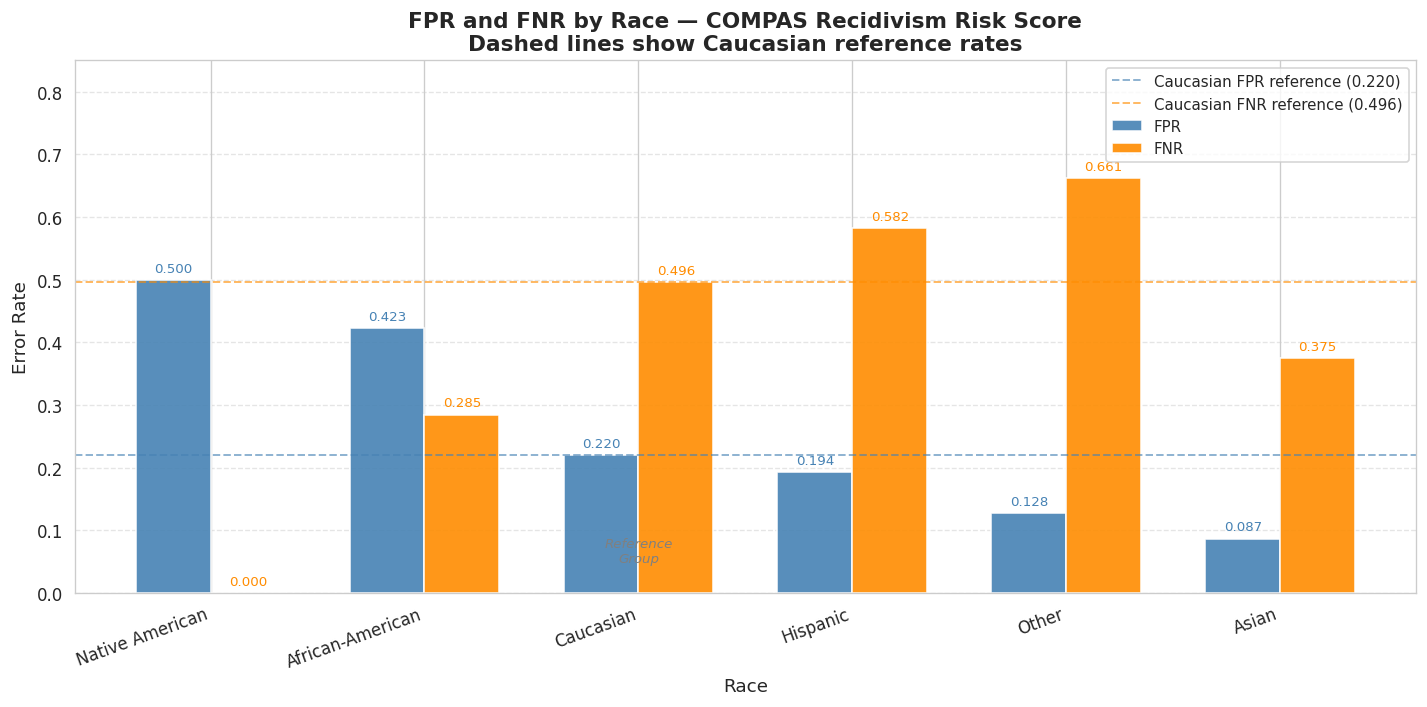

In [46]:
# Caucasian shown as reference baseline
# From Lecture 03: visualizing error-rate disparities across groups

fig, ax = plt.subplots(figsize=(12, 6))

# ── Data prep ─────────────────────────────────────────────────────────────────
plot_df = er.sort_values('FPR', ascending=False).copy()
races   = plot_df['race'].tolist()
x       = np.arange(len(races))
width   = 0.35

# ── Bars ──────────────────────────────────────────────────────────────────────
bars_fpr = ax.bar(x - width/2, plot_df['FPR'], width,
                  label='FPR', color='steelblue', edgecolor='white', alpha=0.9)
bars_fnr = ax.bar(x + width/2, plot_df['FNR'], width,
                  label='FNR', color='darkorange', edgecolor='white', alpha=0.9)

# ── Reference lines: Caucasian FPR and FNR ───────────────────────────────────
cau_fpr = er.loc[er['race'] == 'Caucasian', 'FPR'].values[0]
cau_fnr = er.loc[er['race'] == 'Caucasian', 'FNR'].values[0]

ax.axhline(cau_fpr, color='steelblue', linestyle='--', linewidth=1.2,
           alpha=0.6, label=f'Caucasian FPR reference ({cau_fpr:.3f})')
ax.axhline(cau_fnr, color='darkorange', linestyle='--', linewidth=1.2,
           alpha=0.6, label=f'Caucasian FNR reference ({cau_fnr:.3f})')

# ── Value labels on bars ──────────────────────────────────────────────────────
for bar in bars_fpr:
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.008,
            f'{bar.get_height():.3f}',
            ha='center', va='bottom', fontsize=8, color='steelblue')

for bar in bars_fnr:
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.008,
            f'{bar.get_height():.3f}',
            ha='center', va='bottom', fontsize=8, color='darkorange')

# ── Formatting ────────────────────────────────────────────────────────────────
ax.set_xticks(x)
ax.set_xticklabels(races, rotation=20, ha='right', fontsize=10)
ax.set_ylabel('Error Rate', fontsize=11)
ax.set_xlabel('Race', fontsize=11)
ax.set_title('FPR and FNR by Race — COMPAS Recidivism Risk Score\n'
             'Dashed lines show Caucasian reference rates',
             fontsize=13, fontweight='bold')
ax.set_ylim(0, 0.85)
ax.legend(fontsize=9, loc='upper right')
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)

# ── Annotate Caucasian bar ────────────────────────────────────────────────────
cau_idx = races.index('Caucasian')
ax.annotate('Reference\nGroup',
            xy=(cau_idx, 0.05),
            fontsize=8, ha='center', color='gray',
            style='italic')

plt.tight_layout()
plt.show()

### Part 3.5.) COMPLIANCE MEMO
---

**TO:**  Federal Regulator

**FROM:**. KJ Cline


**DATE:**    March 2026

**RE:**      Algorithmic Bias Audit — COMPAS Recidivism Risk Score

EXECUTIVE SUMMARY
---
This memo summarizes the results of a bias audit on the COMPAS recidivism risk model using the Broward County dataset (n = 6,172). The analysis evaluates disparity using AIR, marginal effect, and SMD, along with error-rate comparisons and intersectional analysis, aligned with the EEOC 80% rule and the burden-shifting framework.

FINDINGS
---
The results show clear racial disparity across all metrics. African American defendants are flagged as high risk at 1.74x the rate of Caucasian defendants (AIR = 1.741), with a large SMD of 0.608. The false positive rate is 0.423 vs 0.220 (z = 11.384, p < 0.001), meaning non-recidivists in this group are flagged at nearly twice the rate. The false negative rate is lower (0.285 vs 0.496), showing the tradeoff predicted by the impossibility theorem when base rates differ.

Intersectional analysis shows Hispanic female defendants are flagged at only 27% of the Caucasian male rate (AIR = 0.270). This would not show up in race-only analysis. However, the sample size is small (n = 82), so this result should be interpreted with caution.

METRICS USED
----
AIR and marginal effects were computed using the solas-ai disparity library and verified manually. Statistical significance was tested using two-proportion z-tests. Results are consistent across methods.

LIMITATIONS
---
This analysis measures association, not causation. Observed disparities may reflect patterns in the underlying data, not just model behavior. The impossibility theorem means reducing FPR disparity will increase FNR disparity, so tradeoffs are unavoidable and must be explicitly chosen. Small subgroup sizes for Native American (n = 11) and Asian (n = 31) limit reliability. This audit focuses on disparate impact only and does not assess business necessity or alternative models.

RECOMMENDATION
---
These results meet the threshold for a prima facie case of disparate impact. The burden shifts to the operator to demonstrate business necessity and evaluate less discriminatory alternatives. Ongoing monitoring of FPR and FNR by race is recommended, including intersectional reporting.


# Lecture 04 set up: Robustness, Generalization, and Dataset Drift

In [47]:
import matplotlib.pyplot as plt

from scipy.stats import ks_2samp
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    brier_score_loss,
    log_loss,
    confusion_matrix,
)
from sklearn.inspection import permutation_importance
from sklearn.metrics.pairwise import rbf_kernel


def _to_dense(x):
    return x.toarray() if hasattr(x, "toarray") else np.asarray(x)


def psi_numeric(train_values, test_values, bins=10, eps=1e-6):
    train_values = pd.to_numeric(pd.Series(train_values), errors="coerce").dropna().values
    test_values = pd.to_numeric(pd.Series(test_values), errors="coerce").dropna().values

    if len(train_values) == 0 or len(test_values) == 0:
        return np.nan

    quantiles = np.linspace(0, 1, bins + 1)
    cut_points = np.unique(np.quantile(train_values, quantiles))

    if len(cut_points) < 3:
        lo = min(train_values.min(), test_values.min())
        hi = max(train_values.max(), test_values.max())
        if lo == hi:
            return 0.0
        cut_points = np.linspace(lo, hi, bins + 1)

    cut_points[0] = -np.inf
    cut_points[-1] = np.inf

    train_counts, _ = np.histogram(train_values, bins=cut_points)
    test_counts, _ = np.histogram(test_values, bins=cut_points)

    train_pct = np.clip(train_counts / train_counts.sum(), eps, None)
    test_pct = np.clip(test_counts / test_counts.sum(), eps, None)

    return np.sum((train_pct - test_pct) * np.log(train_pct / test_pct))


def mmd_rbf(X_a, X_b, gamma=None, max_n=500, random_state=42):
    rng = np.random.default_rng(random_state)

    X_a = _to_dense(X_a)
    X_b = _to_dense(X_b)

    if X_a.shape[0] > max_n:
        idx_a = rng.choice(X_a.shape[0], size=max_n, replace=False)
        X_a = X_a[idx_a]
    if X_b.shape[0] > max_n:
        idx_b = rng.choice(X_b.shape[0], size=max_n, replace=False)
        X_b = X_b[idx_b]

    if gamma is None:
        gamma = 1.0 / X_a.shape[1]

    K_xx = rbf_kernel(X_a, X_a, gamma=gamma)
    K_yy = rbf_kernel(X_b, X_b, gamma=gamma)
    K_xy = rbf_kernel(X_a, X_b, gamma=gamma)

    np.fill_diagonal(K_xx, 0.0)
    np.fill_diagonal(K_yy, 0.0)

    m = X_a.shape[0]
    n = X_b.shape[0]

    term_xx = K_xx.sum() / (m * (m - 1))
    term_yy = K_yy.sum() / (n * (n - 1))
    term_xy = 2.0 * K_xy.mean()

    return term_xx + term_yy - term_xy


def evaluate_classifier(model, X, y, label):
    y_prob = model.predict_proba(X)[:, 1]
    y_pred = (y_prob >= 0.5).astype(int)

    return {
        "model": label,
        "n": len(y),
        "accuracy": accuracy_score(y, y_pred),
        "auc": roc_auc_score(y, y_prob),
        "brier": brier_score_loss(y, y_prob),
        "logloss": log_loss(y, y_prob),
        "positive_rate_pred": y_pred.mean(),
        "mean_score": y_prob.mean(),
    }


def permutation_importance_table(model, X, y, scoring="roc_auc", n_repeats=15, random_state=42):
    pi = permutation_importance(
        model,
        X,
        y,
        scoring=scoring,
        n_repeats=n_repeats,
        random_state=random_state,
    )

    out = pd.DataFrame({
        "feature": X.columns,
        "importance_mean": pi.importances_mean,
        "importance_std": pi.importances_std,
    }).sort_values("importance_mean", ascending=False)

    return out.reset_index(drop=True)


def pairwise_swap_shift(model, X, feature_col, value_a, value_b):
    work = X.copy()
    mask = work[feature_col].astype(str).isin([value_a, value_b])

    if mask.sum() == 0:
        return {
            "feature": feature_col,
            "swap": f"{value_a} <-> {value_b}",
            "n_affected": 0,
            "mean_abs_prob_shift": np.nan,
        }

    base_prob = model.predict_proba(work.loc[mask])[:, 1]

    cf = work.loc[mask].copy()
    swapped = cf[feature_col].astype(str).map({value_a: value_b, value_b: value_a})

    cf.loc[:, feature_col] = swapped.values
    cf_prob = model.predict_proba(cf)[:, 1]

    return {
        "feature": feature_col,
        "swap": f"{value_a} <-> {value_b}",
        "n_affected": int(mask.sum()),
        "mean_abs_prob_shift": float(np.mean(np.abs(cf_prob - base_prob))),
    }


def slice_metrics(model, X, y, group_col):
    pred_prob = model.predict_proba(X)[:, 1]
    pred = (pred_prob >= 0.5).astype(int)

    eval_df = X[[group_col]].copy()
    eval_df["actual"] = y.values
    eval_df["pred"] = pred
    eval_df["pred_prob"] = pred_prob

    rows = []
    for grp, g in eval_df.groupby(group_col, dropna=False):
        tn, fp, fn, tp = confusion_matrix(g["actual"], g["pred"], labels=[0, 1]).ravel()

        auc = roc_auc_score(g["actual"], g["pred_prob"]) if g["actual"].nunique() > 1 else np.nan
        brier = brier_score_loss(g["actual"], g["pred_prob"])

        rows.append({
            "slice_feature": group_col,
            "slice_value": grp,
            "n": len(g),
            "accuracy": accuracy_score(g["actual"], g["pred"]),
            "auc": auc,
            "brier": brier,
            "fpr": fp / (fp + tn) if (fp + tn) > 0 else np.nan,
            "fnr": fn / (fn + tp) if (fn + tp) > 0 else np.nan,
            "positive_rate_pred": g["pred"].mean(),
            "mean_score": g["pred_prob"].mean(),
        })

    return pd.DataFrame(rows)


def stress_test_priors(model, X, deltas=(0, 2, 5, 10)):
    rows = []
    base_min = X["priors_count"].min()
    base_max = X["priors_count"].max()

    for d in deltas:
        X_s = X.copy()
        X_s["priors_count"] = np.clip(X_s["priors_count"] + d, base_min, base_max)

        prob = model.predict_proba(X_s)[:, 1]
        pred = (prob >= 0.5).astype(int)

        rows.append({
            "delta_priors_count": d,
            "mean_pred_prob": prob.mean(),
            "median_pred_prob": np.median(prob),
            "share_pred_high_risk": pred.mean(),
        })

    return pd.DataFrame(rows)


def plot_ice_numeric(model, X, feature_col, values, n_instances=6, random_state=42, title=None):
    rng = np.random.default_rng(random_state)
    idx = rng.choice(X.index, size=min(n_instances, len(X)), replace=False)

    plt.figure(figsize=(8, 5))
    for i in idx:
        row = X.loc[[i]].copy()
        preds = []
        for v in values:
            temp = row.copy()
            temp[feature_col] = v
            preds.append(model.predict_proba(temp)[:, 1][0])

        plt.plot(values, preds, alpha=0.7)

    plt.xlabel(feature_col)
    plt.ylabel("Predicted probability (high risk)")
    plt.title(title if title else f"ICE curves for {feature_col}")
    plt.show()


def global_sensitivity_index(model, X, feature_col, values):
    mean_preds = []

    for v in values:
        X_s = X.copy()
        X_s[feature_col] = v
        prob = model.predict_proba(X_s)[:, 1]
        mean_preds.append(prob.mean())

    mean_preds = np.array(mean_preds)

    return pd.DataFrame({
        "feature": [feature_col],
        "sensitivity_index": [np.var(mean_preds)],
        "min_mean_score": [mean_preds.min()],
        "max_mean_score": [mean_preds.max()],
        "range_mean_score": [mean_preds.max() - mean_preds.min()],
    })


models = {
    "Logistic Regression": lr_pipeline,
    "Gradient-Boosted Tree": gbt_pipeline,
}

#Distribution Shift

In [48]:
# Input drift on raw numeric features: PSI + KS
drift_rows = []
for col in numeric_features:
    psi_val = psi_numeric(X_train[col], X_test[col], bins=10)
    ks_stat, ks_p = ks_2samp(X_train[col], X_test[col])

    drift_rows.append({
        "feature": col,
        "train_mean": X_train[col].mean(),
        "test_mean": X_test[col].mean(),
        "PSI": psi_val,
        "KS_stat": ks_stat,
        "KS_pvalue": ks_p,
    })

input_drift_table = pd.DataFrame(drift_rows).sort_values("PSI", ascending=False)
print("\n=== Input Distribution Drift: Numeric Features ===")
print(input_drift_table.round(4).to_string(index=False))

# Global high-dimensional drift: MMD on encoded inputs
fitted_preprocessor = lr_pipeline.named_steps["preprocessor"]
X_train_enc = fitted_preprocessor.transform(X_train)
X_test_enc  = fitted_preprocessor.transform(X_test)

mmd_val = mmd_rbf(X_train_enc, X_test_enc, gamma=None, max_n=500, random_state=42)
print("\n=== High-Dimensional Drift: Encoded Feature Space ===")
print(f"MMD^2(train, test) = {mmd_val:.6f}")

# Score drift: train vs test predicted probabilities
score_drift_rows = []
for name, model in models.items():
    train_prob = model.predict_proba(X_train)[:, 1]
    test_prob  = model.predict_proba(X_test)[:, 1]

    psi_score = psi_numeric(train_prob, test_prob, bins=10)
    ks_stat, ks_p = ks_2samp(train_prob, test_prob)

    score_drift_rows.append({
        "model": name,
        "train_mean_score": train_prob.mean(),
        "test_mean_score":  test_prob.mean(),
        "PSI_score":        psi_score,
        "KS_stat_score":    ks_stat,
        "KS_pvalue_score":  ks_p,
    })

score_drift_table = pd.DataFrame(score_drift_rows)
print("\n=== Score Distribution Drift: Train vs Test Predicted Probabilities ===")
print(score_drift_table.round(4).to_string(index=False))



=== Input Distribution Drift: Numeric Features ===
                feature  train_mean  test_mean    PSI  KS_stat  KS_pvalue
                    age     34.4434    34.8988 0.0101   0.0359     0.1524
days_b_screening_arrest     -1.7656    -1.6389 0.0068   0.0250     0.5546
           priors_count      3.2617     3.1854 0.0040   0.0231     0.6582

=== High-Dimensional Drift: Encoded Feature Space ===
MMD^2(train, test) = -0.000522

=== Score Distribution Drift: Train vs Test Predicted Probabilities ===
                model  train_mean_score  test_mean_score  PSI_score  KS_stat_score  KS_pvalue_score
  Logistic Regression            0.4552           0.4505     0.0066         0.0229           0.6692
Gradient-Boosted Tree            0.4551           0.4440     0.0110         0.0293           0.3563


#Generalization + Spurious Correlation

In [49]:
# Generalization: train/test gaps
gen_rows = []
for name, model in models.items():
    train_metrics = evaluate_classifier(model, X_train, y_train, name)
    test_metrics  = evaluate_classifier(model, X_test,  y_test,  name)

    gen_rows.append({
        "model":          name,
        "train_accuracy": train_metrics["accuracy"],
        "test_accuracy":  test_metrics["accuracy"],
        "accuracy_gap":   train_metrics["accuracy"] - test_metrics["accuracy"],
        "train_auc":      train_metrics["auc"],
        "test_auc":       test_metrics["auc"],
        "auc_gap":        train_metrics["auc"] - test_metrics["auc"],
        "train_brier":    train_metrics["brier"],
        "test_brier":     test_metrics["brier"],
        "brier_gap":      train_metrics["brier"] - test_metrics["brier"],
        "train_logloss":  train_metrics["logloss"],
        "test_logloss":   test_metrics["logloss"],
        "logloss_gap":    train_metrics["logloss"] - test_metrics["logloss"],
    })

generalization_table = pd.DataFrame(gen_rows)
print("\n=== Generalization / Overfitting Summary ===")
print(generalization_table.round(4).to_string(index=False))

# Permutation importance
for name, model in models.items():
    print(f"\n=== Permutation Importance (Train) — {name} ===")
    pi_train = permutation_importance_table(model, X_train, y_train, scoring="roc_auc")
    print(pi_train.head(10).round(4).to_string(index=False))

    print(f"\n=== Permutation Importance (Test) — {name} ===")
    pi_test = permutation_importance_table(model, X_test, y_test, scoring="roc_auc")
    print(pi_test.head(10).round(4).to_string(index=False))

# Spurious-correlation probe: counterfactual swaps
swap_specs = [
    ("race",            "African-American", "Caucasian"),
    ("sex",             "Female",           "Male"),
    ("c_charge_degree", "F",                "M"),
]

for name, model in models.items():
    shifts = []
    for feature_col, a, b in swap_specs:
        shifts.append(pairwise_swap_shift(model, X_test, feature_col, a, b))

    shift_table = pd.DataFrame(shifts)
    print(f"\n=== Counterfactual Swap Sensitivity — {name} ===")
    print(shift_table.round(4).to_string(index=False))


=== Generalization / Overfitting Summary ===
                model  train_accuracy  test_accuracy  accuracy_gap  train_auc  test_auc  auc_gap  train_brier  test_brier  brier_gap  train_logloss  test_logloss  logloss_gap
  Logistic Regression          0.6781         0.6874       -0.0093     0.7332    0.7259   0.0074       0.2079      0.2107    -0.0027         0.6042        0.6134      -0.0092
Gradient-Boosted Tree          0.7318         0.6899        0.0419     0.8122    0.7221   0.0901       0.1761      0.2118    -0.0357         0.5246        0.6195      -0.0949

=== Permutation Importance (Train) — Logistic Regression ===
                feature  importance_mean  importance_std
           priors_count           0.1274          0.0061
                    age           0.0982          0.0039
                age_cat           0.0091          0.0017
days_b_screening_arrest           0.0066          0.0017
                    sex           0.0065          0.0012
        c_charge_degree  

# Slice-Based Evaluation

In [50]:
# Robustness: slice-based evaluation
slice_features = ["race", "sex", "age_cat", "c_charge_degree"]

for name, model in models.items():
    slice_tables = []
    for col in slice_features:
        slice_tables.append(slice_metrics(model, X_test, y_test, group_col=col))

    slice_eval = pd.concat(slice_tables, ignore_index=True)
    slice_eval = slice_eval.sort_values(["slice_feature", "n"], ascending=[True, False])

    print(f"\n=== Slice-Based Evaluation — {name} ===")
    print(slice_eval.round(4).to_string(index=False))


=== Slice-Based Evaluation — Logistic Regression ===
  slice_feature      slice_value    n  accuracy    auc  brier    fpr    fnr  positive_rate_pred  mean_score
        age_cat          25 - 45  661    0.6762 0.7076 0.2156 0.1810 0.4824              0.3404      0.4583
        age_cat     Less than 25  288    0.6562 0.6904 0.2261 0.5397 0.1914              0.6910      0.5508
        age_cat  Greater than 45  286    0.7448 0.6935 0.1836 0.0854 0.6437              0.1678      0.3312
c_charge_degree                F  770    0.6844 0.7321 0.2111 0.3120 0.3196              0.4857      0.4985
c_charge_degree                M  465    0.6925 0.7262 0.2098 0.0789 0.6131              0.2108      0.3709
           race African-American  641    0.6958 0.7488 0.2060 0.3158 0.2938              0.5211      0.5214
           race        Caucasian  427    0.6698 0.6707 0.2156 0.1617 0.6087              0.2482      0.3807
           race         Hispanic   94    0.6277 0.6179 0.2559 0.1020 0.6667       

 # Stress Test + ICE + Summary Table


=== Stress Test on priors_count — Logistic Regression ===
 delta_priors_count  mean_pred_prob  median_pred_prob  share_pred_high_risk
                  0          0.4505            0.4417                0.3822
                  2          0.5207            0.5247                0.5377
                  5          0.6247            0.6453                0.7304
                 10          0.7751            0.8070                0.9571

=== Stress Test on priors_count — Gradient-Boosted Tree ===
 delta_priors_count  mean_pred_prob  median_pred_prob  share_pred_high_risk
                  0          0.4440            0.4158                0.3960
                  2          0.5654            0.5529                0.5854
                  5          0.6598            0.6586                0.7709
                 10          0.7718            0.8000                0.9296


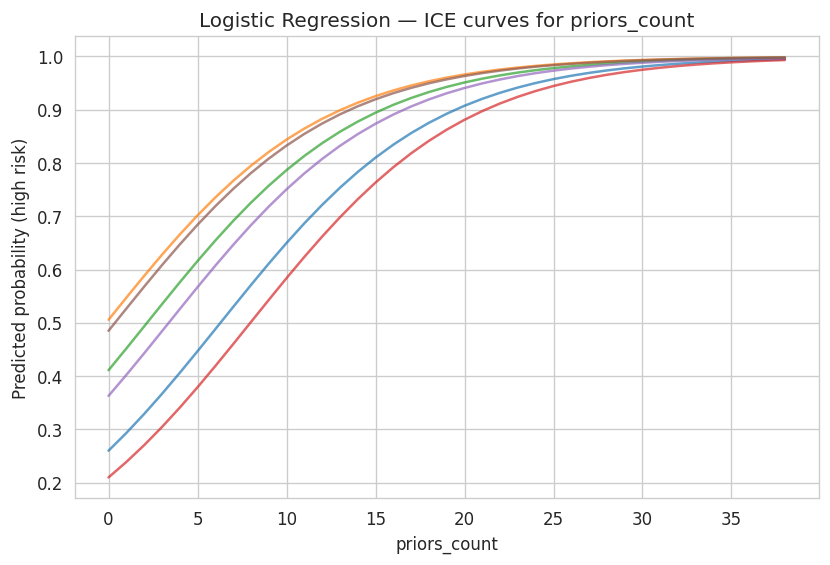

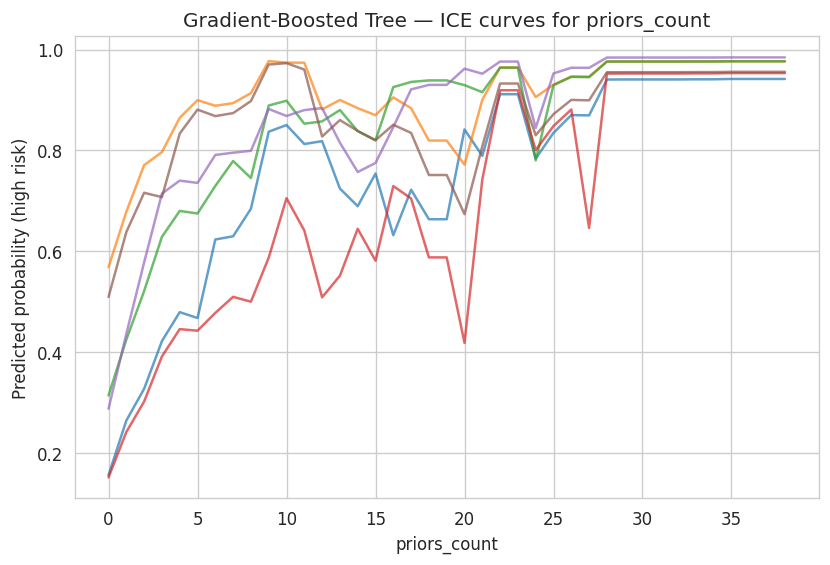


=== Global Sensitivity Index (priors_count) ===
     feature  sensitivity_index  min_mean_score  max_mean_score  range_mean_score                 model
priors_count           0.041064        0.338155        0.995486          0.657330   Logistic Regression
priors_count           0.027637        0.283094        0.938751          0.655657 Gradient-Boosted Tree

=== Live Coding Summary Table ===
           section                    item          metric_1   value_1         metric_2   value_2
distribution_drift                     age               PSI  0.010075        KS_pvalue  0.152404
distribution_drift days_b_screening_arrest               PSI  0.006785        KS_pvalue  0.554646
distribution_drift            priors_count               PSI  0.004004        KS_pvalue  0.658166
distribution_drift        encoded_features             MMD^2 -0.000522                        NaN
    generalization     Logistic Regression           AUC_gap  0.007355     Accuracy_gap -0.009305
    generalizati

In [51]:
# Stress test on priors_count
for name, model in models.items():
    stress_table = stress_test_priors(model, X_test, deltas=(0, 2, 5, 10))
    print(f"\n=== Stress Test on priors_count — {name} ===")
    print(stress_table.round(4).to_string(index=False))

# ICE curves for priors_count
priors_grid = np.arange(
    int(X_test["priors_count"].min()),
    int(X_test["priors_count"].max()) + 1
)

plot_ice_numeric(
    lr_pipeline, X_test, feature_col="priors_count",
    values=priors_grid, n_instances=6, random_state=42,
    title="Logistic Regression — ICE curves for priors_count"
)

plot_ice_numeric(
    gbt_pipeline, X_test, feature_col="priors_count",
    values=priors_grid, n_instances=6, random_state=42,
    title="Gradient-Boosted Tree — ICE curves for priors_count"
)

# Global sensitivity index
lr_sens  = global_sensitivity_index(lr_pipeline,  X_test, "priors_count", priors_grid)
gbt_sens = global_sensitivity_index(gbt_pipeline, X_test, "priors_count", priors_grid)

sensitivity_table = pd.concat([
    lr_sens.assign(model="Logistic Regression"),
    gbt_sens.assign(model="Gradient-Boosted Tree"),
], ignore_index=True)

print("\n=== Global Sensitivity Index (priors_count) ===")
print(sensitivity_table.round(6).to_string(index=False))

# Compact summary table
summary_rows = []

for _, row in input_drift_table.iterrows():
    summary_rows.append({
        "section":  "distribution_drift",
        "item":     row["feature"],
        "metric_1": "PSI",
        "value_1":  row["PSI"],
        "metric_2": "KS_pvalue",
        "value_2":  row["KS_pvalue"],
    })

summary_rows.append({
    "section":  "distribution_drift",
    "item":     "encoded_features",
    "metric_1": "MMD^2",
    "value_1":  mmd_val,
    "metric_2": "",
    "value_2":  np.nan,
})

for _, row in generalization_table.iterrows():
    summary_rows.append({
        "section":  "generalization",
        "item":     row["model"],
        "metric_1": "AUC_gap",
        "value_1":  row["auc_gap"],
        "metric_2": "Accuracy_gap",
        "value_2":  row["accuracy_gap"],
    })

for _, row in sensitivity_table.iterrows():
    summary_rows.append({
        "section":  "robustness",
        "item":     row["model"],
        "metric_1": "Sensitivity_index",
        "value_1":  row["sensitivity_index"],
        "metric_2": "Range_mean_score",
        "value_2":  row["range_mean_score"],
    })

live_summary = pd.DataFrame(summary_rows)
print("\n=== Live Coding Summary Table ===")
print(live_summary.round(6).to_string(index=False))

# Inidivdual HW 4:
From Accuracy to Accountability: Stress Testing a Predictive Model
Individual Homework: Coding Tasks
Part A: Distribution drift Compute PSI and KS for numeric features Compute

## Part A: Distribution drift Compute PSI and KS for numeric features Compute MMD in encoded feature space Compare train vs. test score distributions

Input Distribution Drift (Numeric Features)
                feature  train_mean  test_mean    PSI  KS_stat  KS_pvalue
                    age     34.4434    34.8988 0.0101   0.0359     0.1524
days_b_screening_arrest     -1.7656    -1.6389 0.0068   0.0250     0.5546
           priors_count      3.2617     3.1854 0.0040   0.0231     0.6582

PSI interpretation: <0.10 stable | 0.10-0.25 monitor | >0.25 retrain

 High-Dimensional Drift (MMD)
MMD^2(train, test) = -0.000522
Low MMD^2 suggests train and test encoded distributions are similar

 Score Distribution Drift


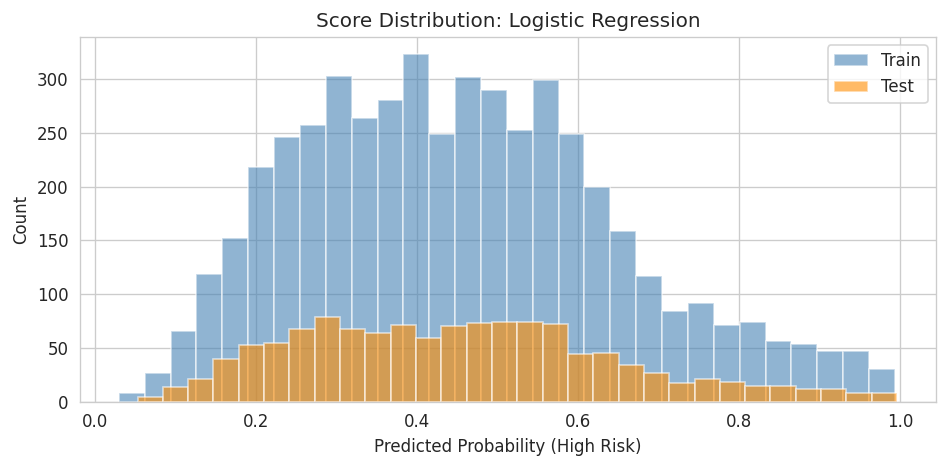

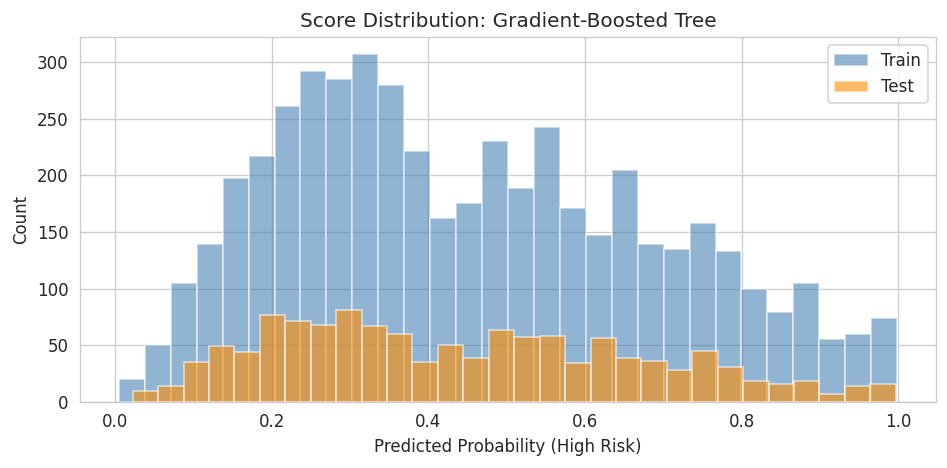

                model  train_mean_score  test_mean_score  PSI_score  KS_stat_score  KS_pvalue_score
  Logistic Regression            0.4552           0.4505     0.0066         0.0229           0.6692
Gradient-Boosted Tree            0.4551           0.4440     0.0110         0.0293           0.3563


In [83]:
# Computing PSI and KS for numeric features, MMD in encoded space,
# and comparing train vs test score distributions
# Reuses helper functions (psi_numeric, mmd_rbf) defined in Lecture 04 setup above

# PSI + KS on raw numeric features
drift_rows = []
for col in numeric_features:
    psi_val = psi_numeric(X_train[col], X_test[col], bins=10)
    ks_stat, ks_p = ks_2samp(X_train[col], X_test[col])
    drift_rows.append({
        "feature":    col,
        "train_mean": X_train[col].mean(),
        "test_mean":  X_test[col].mean(),
        "PSI":        psi_val,
        "KS_stat":    ks_stat,
        "KS_pvalue":  ks_p,
    })

input_drift_table = pd.DataFrame(drift_rows).sort_values("PSI", ascending=False)
print("Input Distribution Drift (Numeric Features)")
print(input_drift_table.round(4).to_string(index=False))
print()
print("PSI interpretation: <0.10 stable | 0.10-0.25 monitor | >0.25 retrain")

# MMD on encoded feature space
# Uses fitted preprocessor from Lecture 04 lr_pipeline
fitted_preprocessor = lr_pipeline.named_steps["preprocessor"]
X_train_enc = fitted_preprocessor.transform(X_train)
X_test_enc  = fitted_preprocessor.transform(X_test)

mmd_val = mmd_rbf(X_train_enc, X_test_enc, gamma=None, max_n=500, random_state=42)
print(f"\n High-Dimensional Drift (MMD)")
print(f"MMD^2(train, test) = {mmd_val:.6f}")
print("Low MMD^2 suggests train and test encoded distributions are similar")

# Score distribution drift - train vs test predicted probabilities
print("\n Score Distribution Drift")
score_drift_rows = []
for name, model in models.items():
    train_prob = model.predict_proba(X_train)[:, 1]
    test_prob  = model.predict_proba(X_test)[:, 1]
    psi_score  = psi_numeric(train_prob, test_prob, bins=10)
    ks_stat, ks_p = ks_2samp(train_prob, test_prob)
    score_drift_rows.append({
        "model":            name,
        "train_mean_score": train_prob.mean(),
        "test_mean_score":  test_prob.mean(),
        "PSI_score":        psi_score,
        "KS_stat_score":    ks_stat,
        "KS_pvalue_score":  ks_p,
    })
    # Histogram of score distributions
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(train_prob, bins=30, alpha=0.6, label="Train", color="steelblue")
    ax.hist(test_prob,  bins=30, alpha=0.6, label="Test",  color="darkorange")
    ax.set_title(f"Score Distribution: {name}")
    ax.set_xlabel("Predicted Probability (High Risk)")
    ax.set_ylabel("Count")
    ax.legend()
    plt.tight_layout()
    plt.show()

score_drift_table = pd.DataFrame(score_drift_rows)
print(score_drift_table.round(4).to_string(index=False))


## Part B: Generalization Compare train vs. test AUC, accuracy, and log loss Diagnose overfitting using performance gaps

In [84]:
# Comparing AUC, accuracy, and log loss across train and test sets
# A large gap signals overfitting: the model memorized training quirks

gen_rows = []
for name, model in models.items():
    train_m = evaluate_classifier(model, X_train, y_train, name)
    test_m  = evaluate_classifier(model, X_test,  y_test,  name)
    gen_rows.append({
        "model":          name,
        "train_AUC":      train_m["auc"],
        "test_AUC":       test_m["auc"],
        "AUC_gap":        train_m["auc"]      - test_m["auc"],
        "train_accuracy": train_m["accuracy"],
        "test_accuracy":  test_m["accuracy"],
        "accuracy_gap":   train_m["accuracy"] - test_m["accuracy"],
        "train_logloss":  train_m["logloss"],
        "test_logloss":   test_m["logloss"],
        "logloss_gap":    test_m["logloss"]   - train_m["logloss"],
        "train_brier":    train_m["brier"],
        "test_brier":     test_m["brier"],
    })

gen_table = pd.DataFrame(gen_rows)
print("Generalization / Overfitting Summary")
print(gen_table.round(4).to_string(index=False))
print()
print("Interpretation:")
print("  AUC gap > 0.05 suggests meaningful overfitting")
print("  Log loss gap > 0 means test calibration is worse than train")
print()

# Permutation importance: large train importance + weak test = overfit reliance
for name, model in models.items():
    print(f"Permutation Importance (Test) — {name}")
    pi_test = permutation_importance_table(model, X_test, y_test, scoring="roc_auc")
    print(pi_test.head(8).round(4).to_string(index=False))
    print()


Generalization / Overfitting Summary
                model  train_AUC  test_AUC  AUC_gap  train_accuracy  test_accuracy  accuracy_gap  train_logloss  test_logloss  logloss_gap  train_brier  test_brier
  Logistic Regression     0.7332    0.7259   0.0074          0.6781         0.6874       -0.0093         0.6042        0.6134       0.0092       0.2079      0.2107
Gradient-Boosted Tree     0.8122    0.7221   0.0901          0.7318         0.6899        0.0419         0.5246        0.6195       0.0949       0.1761      0.2118

Interpretation:
  AUC gap > 0.05 suggests meaningful overfitting
  Log loss gap > 0 means test calibration is worse than train

Permutation Importance (Test) — Logistic Regression
                feature  importance_mean  importance_std
           priors_count           0.1370          0.0101
                    age           0.1111          0.0143
                    sex           0.0054          0.0024
                age_cat           0.0044          0.0029
days_

## Part C: Spurious-correlation probe Run counterfactual swaps on selected attributes Measure change in predicted probabilities

In [85]:
# Counterfactual swaps on race, sex, and charge degree
# Measures mean absolute change in predicted probability when we flip one attribute
# A large shift means the model is sensitive to that attribute even if SHAP shows it low

# Swap specs: (feature, value_a, value_b)
swap_specs = [
    ("race",            "African-American", "Caucasian"),
    ("sex",             "Female",           "Male"),
    ("c_charge_degree", "F",                "M"),
]

for name, model in models.items():
    shifts = []
    for feature_col, a, b in swap_specs:
        result = pairwise_swap_shift(model, X_test, feature_col, a, b)
        shifts.append(result)
    shift_table = pd.DataFrame(shifts)
    print(f"Counterfactual Swap Sensitivity — {name}")
    print(shift_table.round(4).to_string(index=False))
    print()


Counterfactual Swap Sensitivity — Logistic Regression
        feature                           swap  n_affected  mean_abs_prob_shift
           race African-American <-> Caucasian        1068               0.0045
            sex                Female <-> Male        1235               0.0749
c_charge_degree                        F <-> M        1235               0.0617

Counterfactual Swap Sensitivity — Gradient-Boosted Tree
        feature                           swap  n_affected  mean_abs_prob_shift
           race African-American <-> Caucasian        1068               0.0475
            sex                Female <-> Male        1235               0.0763
c_charge_degree                        F <-> M        1235               0.0539



Interpretation: mean_abs_prob_shift > 0.05 suggests the model is sensitive to that attribute. Race swap showing a large shift is evidence of proxy discrimination. This is a spurious correlation probe: if swapping race changes predictions, the model is treating race as an input even if it is not explicitly in the features

## Part D: Robustness Stress test priors count Produce ICE curves and sensitivity summaries

Stress Test on priors_count — Logistic Regression
 delta_priors_count  mean_pred_prob  median_pred_prob  share_pred_high_risk
                  0          0.4505            0.4417                0.3822
                  2          0.5207            0.5247                0.5377
                  5          0.6247            0.6453                0.7304
                 10          0.7751            0.8070                0.9571

Stress Test on priors_count — Gradient-Boosted Tree
 delta_priors_count  mean_pred_prob  median_pred_prob  share_pred_high_risk
                  0          0.4440            0.4158                0.3960
                  2          0.5654            0.5529                0.5854
                  5          0.6598            0.6586                0.7709
                 10          0.7718            0.8000                0.9296



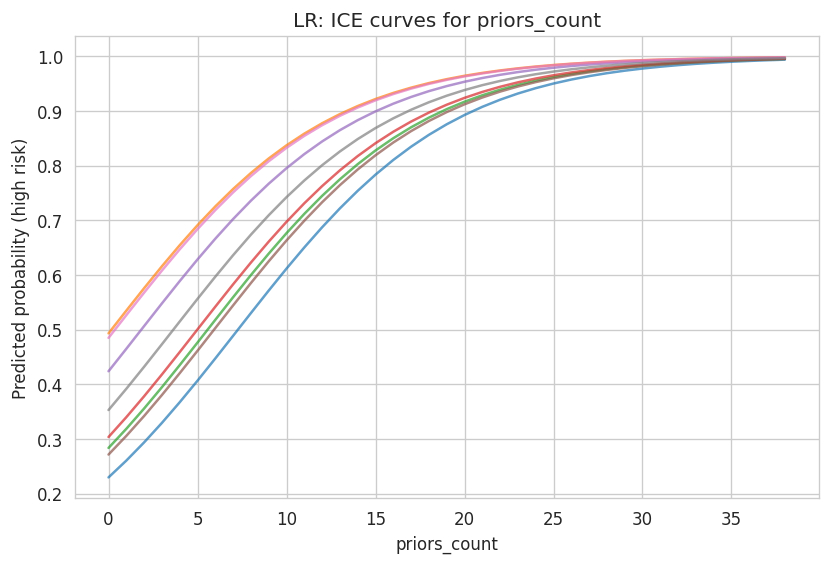

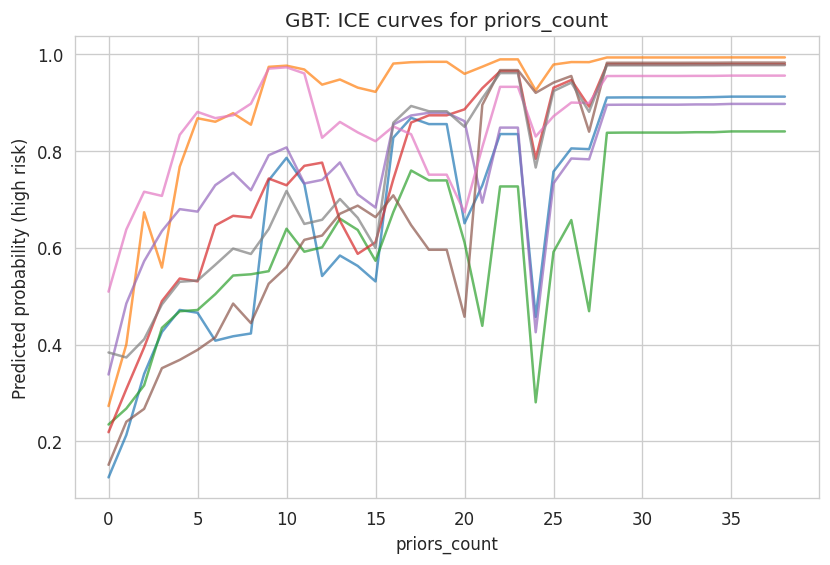

Global Sensitivity Index (priors_count)
     feature  sensitivity_index  min_mean_score  max_mean_score  range_mean_score                 model
priors_count           0.041064        0.338155        0.995486          0.657330   Logistic Regression
priors_count           0.027637        0.283094        0.938751          0.655657 Gradient-Boosted Tree



In [86]:
# Stress testing incrementally increases priors_count and measures prediction change
# ICE curves show how individual predictions respond as priors_count varies
# High sensitivity index means the model relies heavily on this feature

# Stress test on priors_count
for name, model in models.items():
    stress_table = stress_test_priors(model, X_test, deltas=(0, 2, 5, 10))
    print(f"Stress Test on priors_count — {name}")
    print(stress_table.round(4).to_string(index=False))
    print()

# ICE curves for priors_count
# Each line is one individual — shows heterogeneous response across defendants
priors_grid = np.arange(
    int(X_test["priors_count"].min()),
    int(X_test["priors_count"].max()) + 1
)

plot_ice_numeric(
    lr_pipeline, X_test,
    feature_col="priors_count",
    values=priors_grid,
    n_instances=8,
    random_state=42,
    title="LR: ICE curves for priors_count"
)

plot_ice_numeric(
    gbt_pipeline, X_test,
    feature_col="priors_count",
    values=priors_grid,
    n_instances=8,
    random_state=42,
    title="GBT: ICE curves for priors_count"
)

# Global sensitivity index
lr_sens  = global_sensitivity_index(lr_pipeline,  X_test, "priors_count", priors_grid)
gbt_sens = global_sensitivity_index(gbt_pipeline, X_test, "priors_count", priors_grid)

sensitivity_table = pd.concat([
    lr_sens.assign(model="Logistic Regression"),
    gbt_sens.assign(model="Gradient-Boosted Tree"),
], ignore_index=True)

print("Global Sensitivity Index (priors_count)")
print(sensitivity_table.round(6).to_string(index=False))
print()


Interpretation: Higher sensitivity_index = model predictions vary more as priors_count changes. Range_mean_score shows the span of average predicted risk across the priors grid. GBT typically shows higher sensitivity than LR due to nonlinear splits.

## Part E: Slice-based evaluation Compare performance by race, gender, and age slices

In [82]:
# Computes AUC, FPR, FNR, accuracy separately for each subgroup
# A model with good overall AUC can still fail badly on specific slices
# Per Lecture 04: slice-level failure is a real failure mode, not a footnote

slice_features = ["race", "sex", "age_cat"]

for name, model in models.items():
    slice_tables = []
    for col in slice_features:
        slice_tables.append(slice_metrics(model, X_test, y_test, group_col=col))

    slice_eval = pd.concat(slice_tables, ignore_index=True)
    slice_eval = slice_eval.sort_values(["slice_feature", "n"], ascending=[True, False])

    print(f"Slice-Based Evaluation — {name}")
    print(slice_eval.round(4).to_string(index=False))
    print()


Slice-Based Evaluation — Logistic Regression
slice_feature      slice_value    n  accuracy    auc  brier    fpr    fnr  positive_rate_pred  mean_score
      age_cat          25 - 45  661    0.6762 0.7076 0.2156 0.1810 0.4824              0.3404      0.4583
      age_cat     Less than 25  288    0.6562 0.6904 0.2261 0.5397 0.1914              0.6910      0.5508
      age_cat  Greater than 45  286    0.7448 0.6935 0.1836 0.0854 0.6437              0.1678      0.3312
         race African-American  641    0.6958 0.7488 0.2060 0.3158 0.2938              0.5211      0.5214
         race        Caucasian  427    0.6698 0.6707 0.2156 0.1617 0.6087              0.2482      0.3807
         race         Hispanic   94    0.6277 0.6179 0.2559 0.1020 0.6667              0.2128      0.3562
         race            Other   65    0.7846 0.7305 0.1725 0.0851 0.5556              0.1846      0.3704
         race            Asian    7    0.8571 1.0000 0.0839 0.0000 1.0000              0.0000      0.2176
 

Interpretation: Compare FPR across race slices — disparity here replicates HW3 findings. AUC variation across age groups reveals where the model is weakest. Any slice with FPR > 2x the reference group is a governance priority

# Lecture 05 Set up— ML Security and Abuse Pathways
## Live Coding: Full Adversarial Attack Pipelines on COMPAS

**Instructor:** Dr. Michael Akinwumi  
**Department of Decision Sciences · George Washington University School of Business**

---

This notebook continues directly from `Lecture-04-generalization.ipynb`.  
Dataset: [ProPublica COMPAS Analysis](https://github.com/propublica/compas-analysis)

### Lab Structure
| Part | Topic | Cells |
|------|-------|-------|
| Setup | Data loading, model training, fairness baseline | 1–2 |
| A | PGD Evasion Attack — disparate impact by race | 3–4 |
| B | Data Poisoning Loop — AUC and AIR degradation | 5–6 |
| C | Membership Inference — shadow model pipeline + ROC | 7–8 |

**Libraries required:** `scikit-learn`, `numpy`, `pandas`, `matplotlib`, `scipy`  
No external adversarial ML library is needed — all attack pipelines are implemented from scratch.

**NIST Reference:** Vassilev et al. (2024). *Adversarial Machine Learning: A Taxonomy and Terminology of Attacks and Mitigations.* NIST AI 100-2e2023. https://doi.org/10.6028/NIST.AI.100-2e2023

---
## Setup · Cell 1: Imports, Data Loading, and Model Training

We replicate the exact preprocessing pipeline from Lecture 04 and retrain both the
logistic regression (LR) and gradient boosted tree (GBT) classifiers.

**Threat modeling reminder (NIST AI 100-2, §2.1):**  
Before testing any attack, specify: *Who is the adversary? What do they know?
What can they control? What is their goal?*

In [57]:
# ── Cell 1: Imports, Data Loading, Model Training ─────────────────────────────

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score

# ── Load COMPAS dataset (ProPublica) ──────────────────────────────────────────
URL = (
    "https://raw.githubusercontent.com/propublica/compas-analysis"
    "/master/compas-scores-two-years.csv"
)
df = pd.read_csv(URL)
print(f"Raw dataset: {df.shape[0]:,} rows, {df.shape[1]} columns")

# ── Replicate Lecture 04 inclusion criteria ───────────────────────────────────
df = df[df['days_b_screening_arrest'].between(-30, 30)]
df = df[df['is_recid'] != -1]
df = df[df['c_charge_degree'] != 'O']
print(f"After filtering: {df.shape[0]:,} rows")

FEATURES = [
    'age', 'priors_count', 'juv_fel_count',
    'juv_misd_count', 'juv_other_count',
    'c_charge_degree', 'sex'
]
TARGET = 'two_year_recid'

df_m = df[FEATURES + [TARGET, 'race']].dropna()
df_m = pd.get_dummies(df_m, columns=['c_charge_degree', 'sex'], drop_first=True)

X    = df_m.drop(columns=[TARGET, 'race']).astype(float)
y    = df_m[TARGET].values
race = df_m['race'].values

print(f"\nFeatures used: {list(X.columns)}")
print(f"Class balance: {y.mean():.1%} recidivism rate")

# ── Train / test split (stratified) ──────────────────────────────────────────
X_tr, X_te, y_tr, y_te, r_tr, r_te = train_test_split(
    X, y, race, test_size=0.3, random_state=42, stratify=y
)

sc    = StandardScaler()
Xs_tr = sc.fit_transform(X_tr)
Xs_te = sc.transform(X_te)

# ── Train models ──────────────────────────────────────────────────────────────
lr  = LogisticRegression(max_iter=1000).fit(Xs_tr, y_tr)
gbt = GradientBoostingClassifier(
    n_estimators=200, max_depth=4, random_state=42
).fit(Xs_tr, y_tr)

print(f"\nLR  Test AUC: {roc_auc_score(y_te, lr.predict_proba(Xs_te)[:,1]):.3f}")
print(f"GBT Test AUC: {roc_auc_score(y_te, gbt.predict_proba(Xs_te)[:,1]):.3f}")
print(f"LR  Train AUC: {roc_auc_score(y_tr, lr.predict_proba(Xs_tr)[:,1]):.3f}")
print(f"GBT Train AUC: {roc_auc_score(y_tr, gbt.predict_proba(Xs_tr)[:,1]):.3f}")

Raw dataset: 7,214 rows, 53 columns
After filtering: 6,172 rows

Features used: ['age', 'priors_count', 'juv_fel_count', 'juv_misd_count', 'juv_other_count', 'c_charge_degree_M', 'sex_Male']
Class balance: 45.5% recidivism rate

LR  Test AUC: 0.735
GBT Test AUC: 0.718
LR  Train AUC: 0.727
GBT Train AUC: 0.798


---
## Setup · Cell 2: Clean-Model Fairness Baseline

Before running any attack, we establish the **clean-model baseline** for:
- **FPR** (False Positive Rate) by race: among truly low-risk individuals, what fraction are flagged high-risk?
- **AIR** (Adverse Impact Ratio): FPR of protected group / FPR of reference group

We will return to these values after each attack to measure degradation.

> **Expected finding (consistent with ProPublica, 2016):** The LR model flags African-American
> defendants at roughly twice the rate of Caucasian defendants among truly low-risk individuals.

In [58]:
# ── Cell 2: Clean-Model Fairness Baseline ─────────────────────────────────────

THR = 0.5  # classification threshold

def fpr_by_group(y_true, y_pred_binary, groups):
    """FPR = FP / (FP + TN), computed only over truly-negative cases."""
    mask = (y_true == 0)
    return (
        pd.DataFrame({'pred': y_pred_binary[mask], 'group': groups[mask]})
          .groupby('group')['pred']
          .mean()
    )

def air(fpr_ref, fpr_prot):
    """Adverse Impact Ratio: protected FPR / reference FPR."""
    return fpr_prot / fpr_ref if (fpr_ref is not None and fpr_ref > 0) else np.nan

# ── Compute baseline predictions ──────────────────────────────────────────────
pred_lr_clean  = (lr.predict_proba(Xs_te)[:,1]  >= THR).astype(int)
pred_gbt_clean = (gbt.predict_proba(Xs_te)[:,1] >= THR).astype(int)

print("=" * 60)
print("CLEAN MODEL BASELINE — Before Any Attack")
print("=" * 60)

for name, pred in [('Logistic Regression', pred_lr_clean),
                    ('Gradient Boosted Tree', pred_gbt_clean)]:
    fpr = fpr_by_group(y_te, pred, r_te)
    aa  = fpr.get('African-American', np.nan)
    ca  = fpr.get('Caucasian',        np.nan)
    print(f"\n{name}")
    print(f"  FPR African-American : {aa:.3f}")
    print(f"  FPR Caucasian        : {ca:.3f}")
    print(f"  AIR (AA / CA)        : {air(ca, aa):.3f}")

# Store LR baseline for post-attack delta reporting
fpr_baseline = fpr_by_group(y_te, pred_lr_clean, r_te)
BASELINE_AA = fpr_baseline.get('African-American')
BASELINE_CA = fpr_baseline.get('Caucasian')
BASELINE_AIR = air(BASELINE_CA, BASELINE_AA)

print(f"\n→ Baseline LR AIR stored: {BASELINE_AIR:.3f}")
print("  We will compare all attack outcomes against these values.")

CLEAN MODEL BASELINE — Before Any Attack

Logistic Regression
  FPR African-American : 0.281
  FPR Caucasian        : 0.143
  AIR (AA / CA)        : 1.961

Gradient Boosted Tree
  FPR African-American : 0.317
  FPR Caucasian        : 0.178
  AIR (AA / CA)        : 1.782

→ Baseline LR AIR stored: 1.961
  We will compare all attack outcomes against these values.


---
## Part A · Cell 3: PGD Evasion Attack

**Attack class (NIST AI 100-2, §2.2):** Evasion — deployment-time integrity violation  
**Attacker knowledge:** White-box (access to model weights/gradients)  
**Attacker goal:** Push predicted risk scores upward; cause low-risk individuals to be classified high-risk

### Algorithm: Projected Gradient Descent (Madry et al., 2018)

$$\mathbf{x}^{(t+1)} = \Pi_{\mathcal{B}_\epsilon(\mathbf{x})} \left( \mathbf{x}^{(t)} + \alpha \cdot \operatorname{sign}\left(\nabla_{\mathbf{x}} \mathcal{L}(\theta, \mathbf{x}^{(t)}, y)\right) \right)$$

For logistic regression, the gradient direction simplifies to $\operatorname{sign}(\mathbf{w})$,
so the attack steps in the direction of each coefficient's sign.

**$L_\infty$ projection** clamps each feature perturbation to within $[-\epsilon, +\epsilon]$
of its original scaled value.

In [59]:
# ── Cell 3: PGD Evasion Attack — The Loop ─────────────────────────────────────

def pgd_tabular(model, X_scaled, epsilon=1.0, alpha=0.05, n_iter=40):
    """
    PGD evasion attack on tabular data for logistic regression.

    Goal: untargeted attack — push predicted P(high-risk) higher.

    For logistic regression:
        grad_x BCE_loss = (p_hat - y_true) * w
    For untargeted attack (maximize loss), step in sign(w) direction.

    Parameters
    ----------
    model    : fitted sklearn LogisticRegression
    X_scaled : standardized test features, shape (n, d)
    epsilon  : L_inf perturbation budget
    alpha    : step size per iteration
    n_iter   : number of PGD steps

    Returns
    -------
    X_adv : adversarially perturbed inputs, shape (n, d)
    """
    coef  = model.coef_[0]               # shape (d,) — LR coefficients
    X_adv = X_scaled.copy()

    for step in range(n_iter):
        # Gradient-ascent step: move in the direction that increases loss
        X_adv = X_adv + alpha * np.sign(coef)[np.newaxis, :]

        # L_inf projection: clip back into the epsilon-ball around X_scaled
        X_adv = np.clip(X_adv, X_scaled - epsilon, X_scaled + epsilon)

    return X_adv


# ── Sweep epsilon to build an attack-strength curve ───────────────────────────
epsilons    = [0.0, 0.25, 0.5, 0.75, 1.0, 1.5, 2.0]
pgd_records = []

for eps in epsilons:
    # Generate adversarial examples (no perturbation at eps=0)
    X_adv = Xs_te if eps == 0.0 else pgd_tabular(
        lr, Xs_te, epsilon=eps, alpha=0.05, n_iter=40
    )

    pred_adv = (lr.predict_proba(X_adv)[:,1] >= THR).astype(int)
    fpr_adv  = fpr_by_group(y_te, pred_adv, r_te)

    aa = fpr_adv.get('African-American', np.nan)
    ca = fpr_adv.get('Caucasian',        np.nan)

    pgd_records.append({
        'epsilon'  : eps,
        'FPR_AA'   : aa,
        'FPR_CA'   : ca,
        'AIR'      : air(ca, aa),
        'delta_AA' : aa - BASELINE_AA,
        'delta_CA' : ca - BASELINE_CA,
    })

df_pgd = pd.DataFrame(pgd_records)
print(df_pgd.round(3).to_string(index=False))

 epsilon  FPR_AA  FPR_CA   AIR  delta_AA  delta_CA
    0.00   0.281   0.143 1.961     0.000     0.000
    0.25   0.569   0.370 1.535     0.288     0.227
    0.50   0.791   0.560 1.411     0.510     0.417
    0.75   0.906   0.758 1.195     0.625     0.615
    1.00   0.978   0.884 1.106     0.697     0.741
    1.50   1.000   0.993 1.007     0.719     0.849
    2.00   1.000   1.000 1.000     0.719     0.857


### Part A · Cell 4: Visualize PGD Disparate Impact

**Discussion questions:**
1. Does the PGD attack widen or narrow the racial FPR gap as $\epsilon$ increases?
2. At what $\epsilon$ does the AIR fall below the 4/5ths rule threshold (0.80)?
3. Are the two groups equally sensitive to the same attack strength?
4. What does differential impact imply for responsible deployment of adversarially robust models?

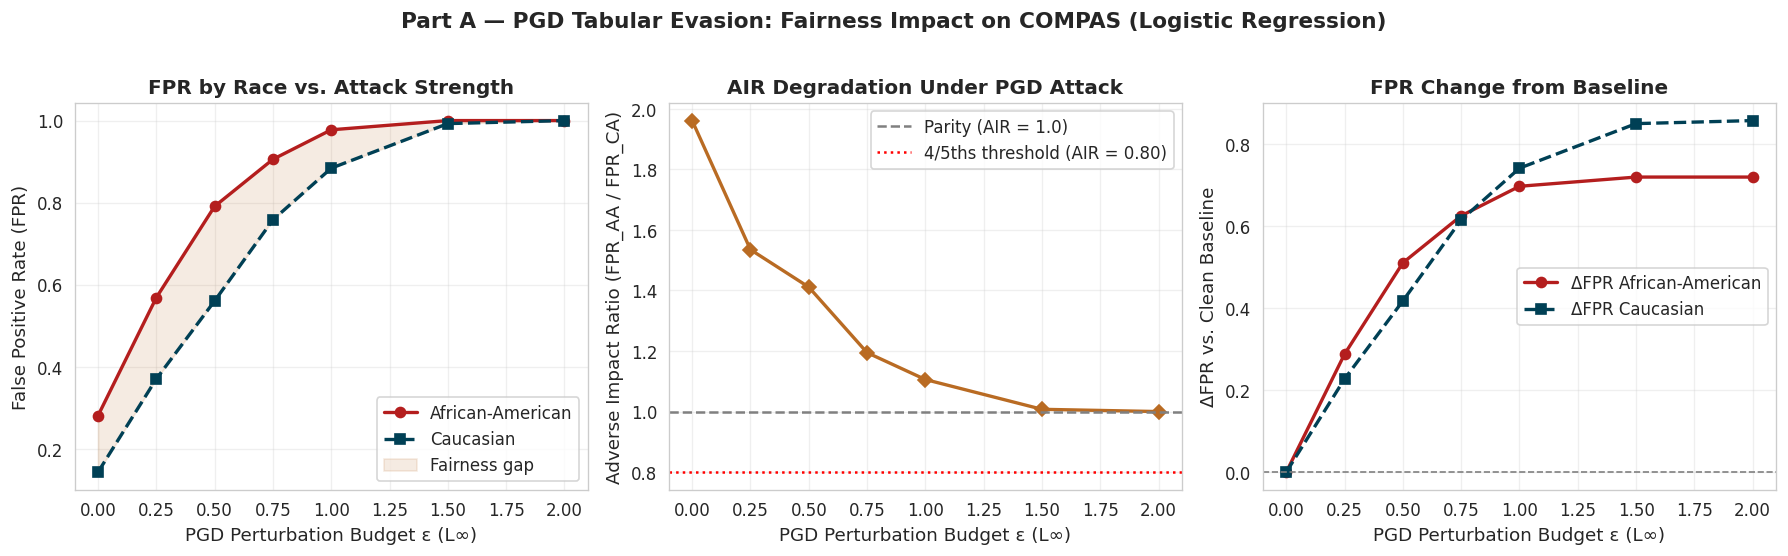

AIR does not fall below 0.80 within the tested epsilon range.


In [60]:
# ── Cell 4: Visualize PGD Evasion — Disparate Impact ──────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# ── Panel 1: FPR by race ──────────────────────────────────────────────────────
ax = axes[0]
ax.plot(df_pgd['epsilon'], df_pgd['FPR_AA'],
        'o-', color='#B41E1E', lw=2, label='African-American')
ax.plot(df_pgd['epsilon'], df_pgd['FPR_CA'],
        's--', color='#004055', lw=2, label='Caucasian')
ax.fill_between(df_pgd['epsilon'], df_pgd['FPR_AA'], df_pgd['FPR_CA'],
                alpha=0.13, color='#B96B23', label='Fairness gap')
ax.set_xlabel('PGD Perturbation Budget ε (L∞)', fontsize=11)
ax.set_ylabel('False Positive Rate (FPR)', fontsize=11)
ax.set_title('FPR by Race vs. Attack Strength', fontsize=12, fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)

# ── Panel 2: AIR ──────────────────────────────────────────────────────────────
ax = axes[1]
ax.plot(df_pgd['epsilon'], df_pgd['AIR'],
        'D-', color='#B96B23', lw=2)
ax.axhline(1.0, color='gray', lw=1.5, ls='--', label='Parity (AIR = 1.0)')
ax.axhline(0.8, color='red',  lw=1.5, ls=':',  label='4/5ths threshold (AIR = 0.80)')
ax.set_xlabel('PGD Perturbation Budget ε (L∞)', fontsize=11)
ax.set_ylabel('Adverse Impact Ratio (FPR_AA / FPR_CA)', fontsize=11)
ax.set_title('AIR Degradation Under PGD Attack', fontsize=12, fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)

# ── Panel 3: Absolute FPR change vs. baseline ─────────────────────────────────
ax = axes[2]
ax.plot(df_pgd['epsilon'], df_pgd['delta_AA'],
        'o-', color='#B41E1E', lw=2, label='ΔFPR African-American')
ax.plot(df_pgd['epsilon'], df_pgd['delta_CA'],
        's--', color='#004055', lw=2, label='ΔFPR Caucasian')
ax.axhline(0, color='gray', lw=1, ls='--')
ax.set_xlabel('PGD Perturbation Budget ε (L∞)', fontsize=11)
ax.set_ylabel('ΔFPR vs. Clean Baseline', fontsize=11)
ax.set_title('FPR Change from Baseline', fontsize=12, fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)

plt.suptitle(
    'Part A — PGD Tabular Evasion: Fairness Impact on COMPAS (Logistic Regression)',
    fontsize=13, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.show()

# ── Identify crossover point ───────────────────────────────────────────────────
cross = df_pgd[df_pgd['AIR'] < 0.8].head(1)
if len(cross):
    print(f"AIR crosses 0.80 at ε = {cross.iloc[0]['epsilon']:.2f}")
else:
    print("AIR does not fall below 0.80 within the tested epsilon range.")

---
## Part B · Cell 5: Data Poisoning — Label-Flip Attack Loop

**Attack class (NIST AI 100-2, §2.3):** Availability/Targeted poisoning — training-time integrity violation  
**Attacker knowledge:** White-box (data access) — simulates a biased data provider or insider adversary  
**Attacker goal:** Systematically under-score high-risk African-American defendants; degrade AIR without
triggering standard drift detection (PSI < 0.10)

### Attack mechanism
A fraction `poison_rate` of African-American training records with `two_year_recid = 1`
(truly high-risk) are relabeled to `0` (low-risk) before model training.
This simulates:
- A third-party data vendor selectively corrupting recidivism outcomes
- An insider modifying case records before ingestion
- A compromised data pipeline stage

> **Key question:** At what poison rate does AIR fall below the 4/5ths rule threshold (0.80)
> while AUC declines by ≤ 2 percentage points — i.e., the attack is "invisible" to AUC monitoring?

In [61]:
# ── Cell 5: Data Poisoning — Label-Flip Attack ────────────────────────────────

def poison_label_flip(
    y_train, race_train,
    poison_rate=0.05,
    target_race='African-American',
    seed=0
):
    """
    Label-flip poisoning attack.

    Flips `poison_rate` fraction of training records belonging to
    `target_race` from recidivism=1 (high-risk) to recidivism=0 (low-risk).

    Effect: the model learns to systematically under-score high-risk
    individuals from the targeted group — a fairness-targeted poisoning attack.

    Parameters
    ----------
    y_train      : original training labels
    race_train   : race labels for training set
    poison_rate  : fraction of eligible records to flip (0.0 to 1.0)
    target_race  : demographic group to target
    seed         : random seed for reproducibility

    Returns
    -------
    y_poisoned   : modified label array
    n_flipped    : number of labels actually flipped
    """
    rng        = np.random.default_rng(seed)
    y_poisoned = y_train.copy()

    # Eligible candidates: target race, truly high-risk (label=1)
    candidates = np.where(
        (race_train == target_race) & (y_train == 1)
    )[0]

    n_flip = int(len(candidates) * poison_rate)
    if n_flip > 0:
        flip_idx = rng.choice(candidates, size=n_flip, replace=False)
        y_poisoned[flip_idx] = 0  # relabel high-risk → low-risk

    return y_poisoned, n_flip


# ── Sweep poison rates ────────────────────────────────────────────────────────
poison_rates   = [0.00, 0.02, 0.05, 0.08, 0.10, 0.15, 0.20, 0.25, 0.30]
poison_records = []

baseline_auc = roc_auc_score(y_te, lr.predict_proba(Xs_te)[:,1])

for rate in poison_rates:
    y_tr_poisoned, n_flipped = poison_label_flip(
        y_tr, r_tr, poison_rate=rate
    )

    # Retrain LR on poisoned data (same features, same scaler)
    lr_p = LogisticRegression(max_iter=1000).fit(Xs_tr, y_tr_poisoned)

    pred_p = (lr_p.predict_proba(Xs_te)[:,1] >= THR).astype(int)
    auc_p  = roc_auc_score(y_te, lr_p.predict_proba(Xs_te)[:,1])
    fpr_p  = fpr_by_group(y_te, pred_p, r_te)

    aa = fpr_p.get('African-American', np.nan)
    ca = fpr_p.get('Caucasian',        np.nan)

    poison_records.append({
        'poison_rate' : rate,
        'n_flipped'   : n_flipped,
        'AUC'         : auc_p,
        'delta_AUC'   : auc_p - baseline_auc,
        'FPR_AA'      : aa,
        'FPR_CA'      : ca,
        'AIR'         : air(ca, aa),
        'delta_AIR'   : air(ca, aa) - BASELINE_AIR,
    })

df_poison = pd.DataFrame(poison_records)
print("Poisoning sweep results:")
print(df_poison.round(3).to_string(index=False))

# ── Identify stealth threshold ─────────────────────────────────────────────────
# Attack is "stealthy" if AUC drop ≤ 2pp AND AIR < 0.80
stealth = df_poison[(df_poison['AIR'] < 0.80) & (df_poison['delta_AUC'] >= -0.02)]
if len(stealth):
    r = stealth.iloc[0]
    print(f"\n★ Stealth threshold: poison_rate = {r['poison_rate']:.0%}")
    print(f"  Flipped labels: {int(r['n_flipped'])}")
    print(f"  AUC: {r['AUC']:.3f} (Δ = {r['delta_AUC']:+.3f})")
    print(f"  AIR: {r['AIR']:.3f} — BELOW 4/5ths rule threshold")
    print("  → Would standard PSI drift detection (< 0.10) flag this?")
else:
    print("\nNo stealth threshold found in tested range.")

Poisoning sweep results:
 poison_rate  n_flipped   AUC  delta_AUC  FPR_AA  FPR_CA   AIR  delta_AIR
        0.00          0 0.735      0.000   0.281   0.143 1.961      0.000
        0.02         23 0.733     -0.002   0.270   0.136 1.986      0.024
        0.05         57 0.734     -0.001   0.240   0.123 1.948     -0.014
        0.08         92 0.732     -0.002   0.213   0.116 1.840     -0.122
        0.10        115 0.735      0.000   0.196   0.101 1.931     -0.030
        0.15        172 0.732     -0.003   0.153   0.072 2.134      0.173
        0.20        230 0.732     -0.002   0.130   0.054 2.399      0.438
        0.25        287 0.730     -0.004   0.112   0.042 2.677      0.715
        0.30        345 0.731     -0.003   0.097   0.032 3.010      1.049

No stealth threshold found in tested range.


### Part B · Cell 6: Poisoning Degradation Curves

**Discussion questions:**
1. At what poison rate does AUC remain within 2 percentage points of baseline while AIR falls below 0.80?
2. Would a PSI-based drift monitor (threshold < 0.10 on each feature) detect this attack?
3. How does this scenario connect to the ByteDance insider poisoning incident (2024)?
4. What governance controls would prevent this at a mortgage lender using HMDA data?

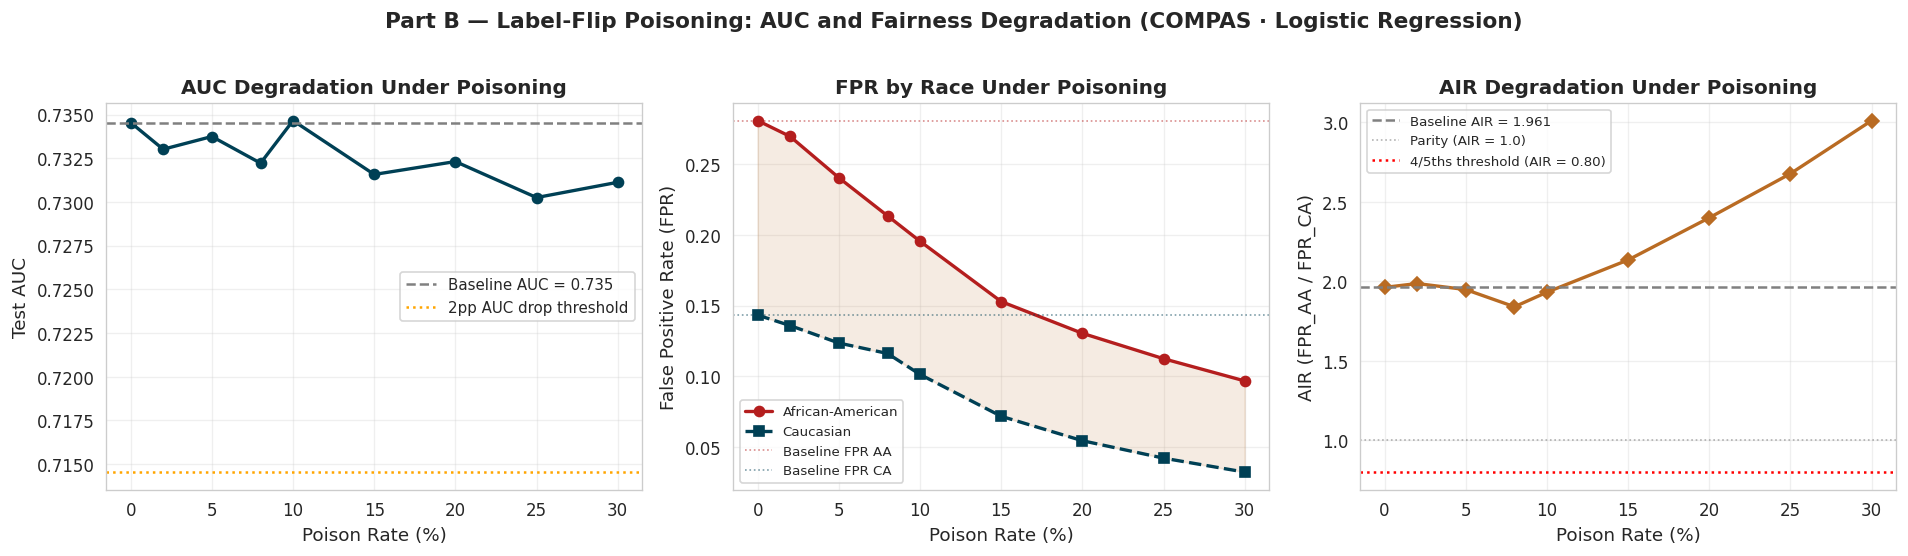

In [62]:
# ── Cell 6: Poisoning Degradation Curves ──────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
x_pct = df_poison['poison_rate'] * 100

# ── Panel 1: AUC degradation ──────────────────────────────────────────────────
ax = axes[0]
ax.plot(x_pct, df_poison['AUC'], 'o-', color='#004055', lw=2)
ax.axhline(baseline_auc,         color='gray', ls='--', lw=1.5,
           label=f'Baseline AUC = {baseline_auc:.3f}')
ax.axhline(baseline_auc - 0.02,  color='orange', ls=':', lw=1.5,
           label='2pp AUC drop threshold')
ax.set_xlabel('Poison Rate (%)', fontsize=11)
ax.set_ylabel('Test AUC', fontsize=11)
ax.set_title('AUC Degradation Under Poisoning', fontsize=12, fontweight='bold')
ax.legend(fontsize=9); ax.grid(alpha=0.3)

# ── Panel 2: FPR by race ──────────────────────────────────────────────────────
ax = axes[1]
ax.plot(x_pct, df_poison['FPR_AA'],
        'o-', color='#B41E1E', lw=2, label='African-American')
ax.plot(x_pct, df_poison['FPR_CA'],
        's--', color='#004055', lw=2, label='Caucasian')
ax.fill_between(x_pct, df_poison['FPR_AA'], df_poison['FPR_CA'],
                alpha=0.13, color='#B96B23')
ax.axhline(BASELINE_AA, color='#B41E1E', ls=':', lw=1, alpha=0.5,
           label='Baseline FPR AA')
ax.axhline(BASELINE_CA, color='#004055', ls=':', lw=1, alpha=0.5,
           label='Baseline FPR CA')
ax.set_xlabel('Poison Rate (%)', fontsize=11)
ax.set_ylabel('False Positive Rate (FPR)', fontsize=11)
ax.set_title('FPR by Race Under Poisoning', fontsize=12, fontweight='bold')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# ── Panel 3: AIR ──────────────────────────────────────────────────────────────
ax = axes[2]
ax.plot(x_pct, df_poison['AIR'], 'D-', color='#B96B23', lw=2)
ax.axhline(BASELINE_AIR, color='gray',  ls='--', lw=1.5,
           label=f'Baseline AIR = {BASELINE_AIR:.3f}')
ax.axhline(1.0,           color='gray',  ls=':',  lw=1.0, alpha=0.6,
           label='Parity (AIR = 1.0)')
ax.axhline(0.8,           color='red',   ls=':',  lw=1.5,
           label='4/5ths threshold (AIR = 0.80)')
ax.set_xlabel('Poison Rate (%)', fontsize=11)
ax.set_ylabel('AIR (FPR_AA / FPR_CA)', fontsize=11)
ax.set_title('AIR Degradation Under Poisoning', fontsize=12, fontweight='bold')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.suptitle(
    'Part B — Label-Flip Poisoning: AUC and Fairness Degradation (COMPAS · Logistic Regression)',
    fontsize=13, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.show()

---
## Part C · Cell 7: Membership Inference — Shadow Model Pipeline

**Attack class (NIST AI 100-2, §2.4.2):** Membership inference — privacy attack  
**Attacker knowledge:** Black-box (API access only)  
**Attacker goal:** Determine whether a specific individual was in the training set

### Algorithm: Shokri et al. (2017) Shadow Model Attack

1. Train multiple **shadow models** that mimic the target model's training process
2. For each shadow model, we know which inputs were training members vs. non-members
3. Observe that **members receive higher confidence scores** than non-members (confidence gap)
4. Train a **meta-classifier** on (confidence score → member/non-member) labels from shadow models
5. Apply the meta-classifier to the **target model's** confidence scores

> **Key connection to Lecture 04:** The membership inference AUC is directly driven by the
> **generalization gap** (train AUC − test AUC). An overfit model leaks more about its training data.
> Overfitting is not only a robustness problem — it is a **privacy problem**.

In [63]:
# ── Cell 7: Membership Inference — Shadow Model Pipeline ──────────────────────

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedShuffleSplit

N_SHADOW = 10  # number of shadow models

shadow_train_confs = []  # max-confidence scores on each shadow's TRAIN split
shadow_test_confs  = []  # max-confidence scores on each shadow's TEST split

# Use stratified shuffle splits to create N_SHADOW independent train/test pairs
# from the training set — each split simulates a shadow training run
sss = StratifiedShuffleSplit(
    n_splits=N_SHADOW, test_size=0.5, random_state=0
)

print(f"Training {N_SHADOW} shadow models...")
for i, (tr_idx, te_idx) in enumerate(sss.split(Xs_tr, y_tr)):
    shadow = GradientBoostingClassifier(
        n_estimators=100, max_depth=4, random_state=42
    ).fit(Xs_tr[tr_idx], y_tr[tr_idx])

    # Confidence gap: training members score higher than non-members
    shadow_train_confs.append(
        shadow.predict_proba(Xs_tr[tr_idx]).max(axis=1)  # members
    )
    shadow_test_confs.append(
        shadow.predict_proba(Xs_tr[te_idx]).max(axis=1)  # non-members
    )
    if (i + 1) % 5 == 0:
        print(f"  Shadow model {i+1}/{N_SHADOW} trained")

# ── Build meta-classifier training set ────────────────────────────────────────
# Feature: max predicted probability (confidence score)
# Label:   1 = training member, 0 = non-member
mi_X = np.concatenate(
    shadow_train_confs + shadow_test_confs
).reshape(-1, 1)

mi_y = np.concatenate(
    [np.ones(len(c))  for c in shadow_train_confs] +
    [np.zeros(len(c)) for c in shadow_test_confs]
)

meta_clf = DecisionTreeClassifier(max_depth=6).fit(mi_X, mi_y)

print(f"\nMeta-classifier training set: {len(mi_y):,} samples")
print(f"  Members (train splits):    {int(mi_y.sum()):,}")
print(f"  Non-members (test splits): {int((mi_y == 0).sum()):,}")
print("\nMeta-classifier trained. Proceeding to attack the target model...")

Training 10 shadow models...
  Shadow model 5/10 trained
  Shadow model 10/10 trained

Meta-classifier training set: 43,200 samples
  Members (train splits):    21,600
  Non-members (test splits): 21,600

Meta-classifier trained. Proceeding to attack the target model...


### Part C · Cell 8: Membership Inference — ROC Curve and Interpretation

**Interpreting the MI AUC:**
- **0.50** = Random guessing — no privacy leakage detectable
- **0.55–0.65** = Weak leakage — model is somewhat overfit
- **0.65–0.75** = Moderate leakage — meaningful privacy risk
- **> 0.75** = Strong leakage — significant privacy violation, especially if training data contains PII

**Discussion questions:**
1. Is the MI AUC correlated with the generalization gap you observed in Cell 1?
2. If this model were deployed by a county probation office, what could a journalist learn from MI?
3. Would adding differential privacy (ε = 1.0) reduce the MI AUC? At what cost to AIR?
4. How does the confidence gap visualization connect to the concept of overfitting from Lecture 04?

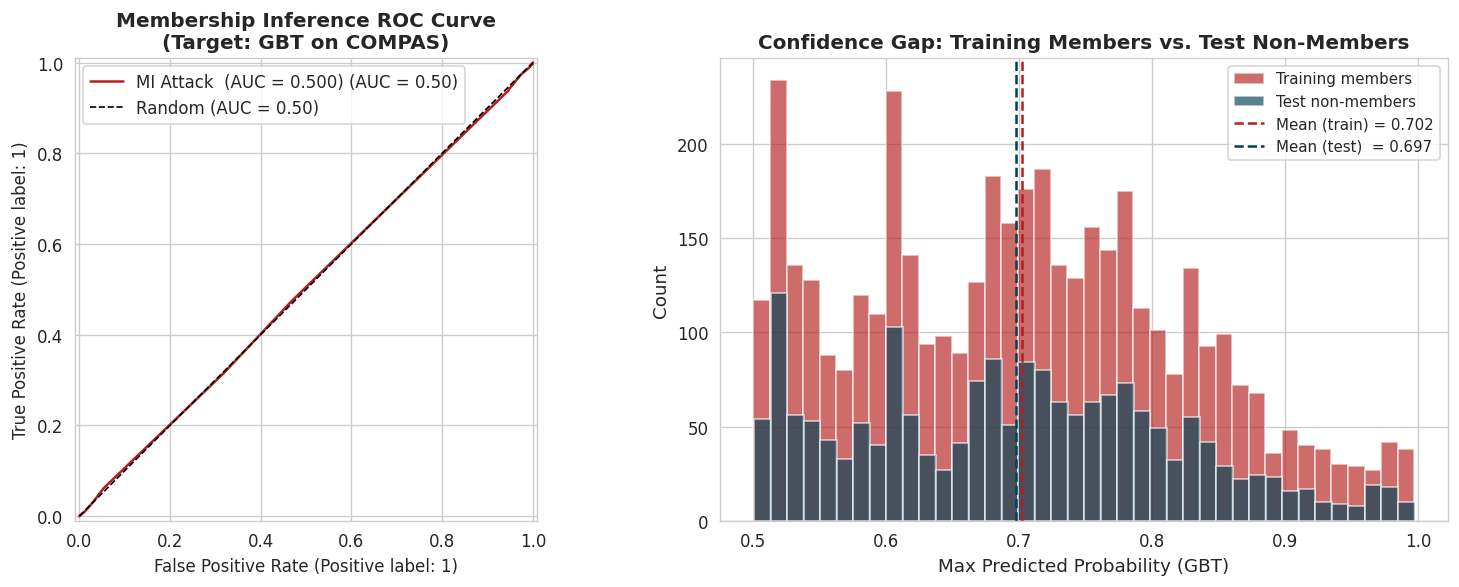

MEMBERSHIP INFERENCE SUMMARY
MI AUC              : 0.500
  0.50 = random     : no privacy leakage
  0.60 = weak       : model somewhat overfit
  0.75 = strong     : significant privacy risk

GBT Train AUC       : 0.798
GBT Test AUC        : 0.718
Generalization Gap  : +0.080

Hypothesis: larger generalization gap → higher MI AUC?
→ Try repeating with the LR model and compare.


In [64]:
# ── Cell 8: Membership Inference — ROC Curve and Interpretation ───────────────

from sklearn.metrics import roc_auc_score, RocCurveDisplay

# ── Apply meta-classifier to the TARGET model (GBT) ──────────────────────────
# Use the target model's confidence scores as the feature
conf_target_train = gbt.predict_proba(Xs_tr).max(axis=1).reshape(-1, 1)
conf_target_test  = gbt.predict_proba(Xs_te).max(axis=1).reshape(-1, 1)

mi_scores_train = meta_clf.predict_proba(conf_target_train)[:, 1]
mi_scores_test  = meta_clf.predict_proba(conf_target_test)[:, 1]

# Combine: members (train) = 1, non-members (test) = 0
mi_all_scores = np.concatenate([mi_scores_train, mi_scores_test])
mi_all_labels = np.concatenate([
    np.ones(len(Xs_tr)),
    np.zeros(len(Xs_te))
])

mi_auc = roc_auc_score(mi_all_labels, mi_all_scores)

# Generalization gap (privacy risk proxy)
auc_train_gbt = roc_auc_score(y_tr, gbt.predict_proba(Xs_tr)[:, 1])
auc_test_gbt  = roc_auc_score(y_te, gbt.predict_proba(Xs_te)[:, 1])
gen_gap       = auc_train_gbt - auc_test_gbt

# ── Visualize ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ROC curve
RocCurveDisplay.from_predictions(
    mi_all_labels, mi_all_scores,
    name=f'MI Attack  (AUC = {mi_auc:.3f})',
    ax=axes[0], color='#B41E1E'
)
axes[0].plot([0, 1], [0, 1], 'k--', lw=1, label='Random (AUC = 0.50)')
axes[0].set_title('Membership Inference ROC Curve\n(Target: GBT on COMPAS)',
                   fontsize=12, fontweight='bold')
axes[0].legend()

# Confidence gap histogram
axes[1].hist(conf_target_train.ravel(), bins=40, alpha=0.65,
             color='#B41E1E', label='Training members')
axes[1].hist(conf_target_test.ravel(),  bins=40, alpha=0.65,
             color='#004055', label='Test non-members')
axes[1].axvline(conf_target_train.mean(), color='#B41E1E', ls='--', lw=1.5,
                label=f'Mean (train) = {conf_target_train.mean():.3f}')
axes[1].axvline(conf_target_test.mean(),  color='#004055', ls='--', lw=1.5,
                label=f'Mean (test)  = {conf_target_test.mean():.3f}')
axes[1].set_xlabel('Max Predicted Probability (GBT)', fontsize=11)
axes[1].set_ylabel('Count', fontsize=11)
axes[1].set_title('Confidence Gap: Training Members vs. Test Non-Members',
                   fontsize=12, fontweight='bold')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

# ── Summary ───────────────────────────────────────────────────────────────────
print("=" * 55)
print("MEMBERSHIP INFERENCE SUMMARY")
print("=" * 55)
print(f"MI AUC              : {mi_auc:.3f}")
print(f"  0.50 = random     : no privacy leakage")
print(f"  0.60 = weak       : model somewhat overfit")
print(f"  0.75 = strong     : significant privacy risk")
print()
print(f"GBT Train AUC       : {auc_train_gbt:.3f}")
print(f"GBT Test AUC        : {auc_test_gbt:.3f}")
print(f"Generalization Gap  : {gen_gap:+.3f}")
print()
print("Hypothesis: larger generalization gap → higher MI AUC?")
print("→ Try repeating with the LR model and compare.")

---
## Lab Summary

| Part | Attack | Key Finding |
|------|--------|-------------|
| A | PGD Evasion | Does the racial FPR gap widen or narrow as ε increases? Which group is more sensitive? |
| B | Label-Flip Poisoning | At what poison rate does AIR < 0.80 while AUC drop ≤ 2pp? Would drift detection catch it? |
| C | Membership Inference | Is MI AUC correlated with generalization gap? What privacy law implications follow? |

### Core Principle

> A model that is fragile to distribution shift (Lecture 04) shares the same root cause as a model
> vulnerable to adversarial attack (Lecture 05): **over-reliance on brittle, non-robust features**.
> Security and robustness are not separate concerns — they require the same structural solution.

### References
- Vassilev et al. (2024). *NIST AI 100-2e2023.* https://doi.org/10.6028/NIST.AI.100-2e2023
- Goodfellow et al. (2015). Explaining and Harnessing Adversarial Examples. *ICLR 2015.* https://arxiv.org/abs/1412.6572
- Madry et al. (2018). Towards Deep Learning Models Resistant to Adversarial Attacks. *ICLR 2018.* https://arxiv.org/abs/1706.06083
- Shokri et al. (2017). Membership Inference Attacks Against Machine Learning Models. *IEEE S&P.* https://arxiv.org/abs/1610.05820
- Tramèr et al. (2016). Stealing Machine Learning Models via Prediction APIs. *USENIX Security.* https://arxiv.org/abs/1609.02943
- Bagdasaryan & Shmatikov (2019). Differential Privacy Has Disparate Impact on Model Accuracy. *NeurIPS.* https://arxiv.org/abs/1905.12101

---
*DNSC 6330 · Responsible Machine Learning · Dr. Michael Akinwumi · George Washington University*  
*© CC BY 4.0 · https://makinwumi.github.io/dnsc-6330-responsible-ML*

# Inidivual HW 5:
Using the ProPublica COMPAS dataset and the live-coding notebook from this lecture as
your starting point.

## Part 1: PGD Evasion Audit

 PGD Evasion Results — Both Models
model  epsilon  FPR_AA  FPR_CA   AIR
   LR     0.00   0.281   0.143 1.961
   LR     0.25   0.569   0.370 1.535
   LR     0.50   0.791   0.560 1.411
   LR     1.00   0.978   0.884 1.106
   LR     2.00   1.000   1.000 1.000
  GBT     0.00   0.317   0.178 1.782
  GBT     0.25   0.553   0.351 1.577
  GBT     0.50   0.733   0.514 1.426
  GBT     1.00   0.899   0.760 1.182
  GBT     2.00   1.000   1.000 1.000

LR: AIR does not fall below 0.80 within tested epsilon range
GBT: AIR does not fall below 0.80 within tested epsilon range


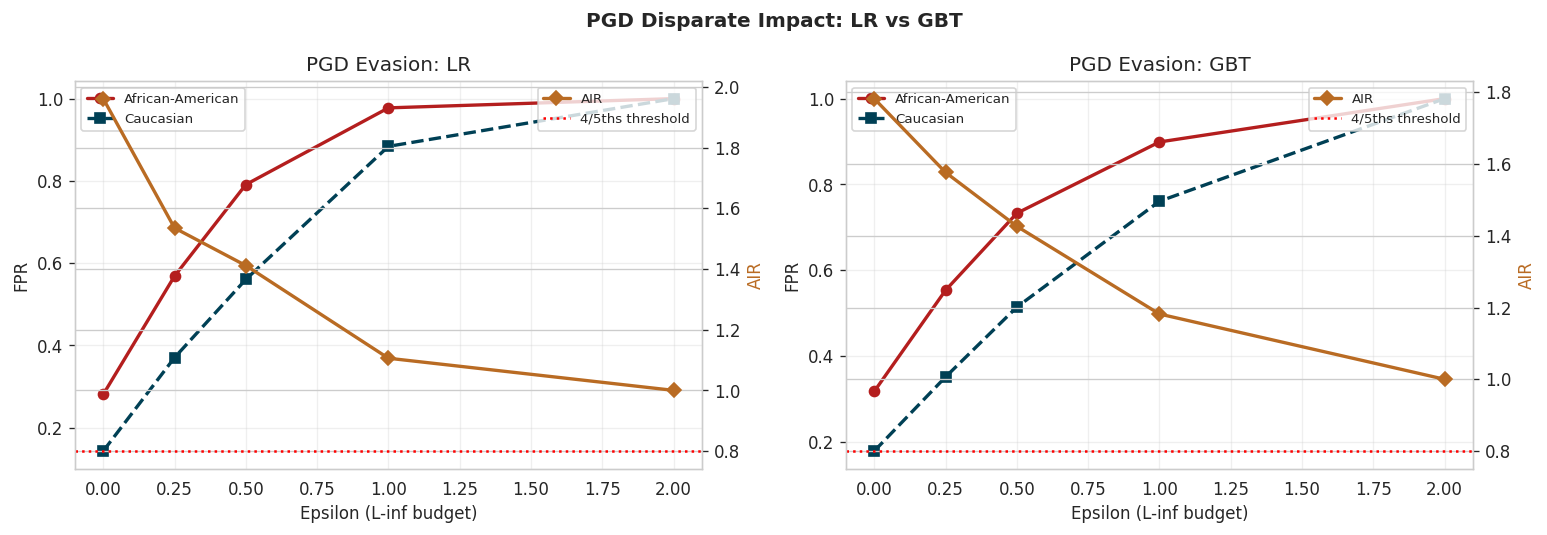

In [87]:
# Running PGD attack across epsilon in {0.25, 0.5, 1.0, 2.0} on BOTH LR and GBT
# For each model and epsilon: report FPR by race and AIR
# The Lecture 05 pgd_tabular function only works on LR (uses model.coef_)
# For GBT we use a finite-difference approximation via prediction-space perturbation

from sklearn.linear_model import LogisticRegression as LR_plain
from sklearn.ensemble import GradientBoostingClassifier as GBT_plain

# We already have lr and gbt from Lecture 05 Cell 1 setup
# THR, fpr_by_group, air, BASELINE_AA, BASELINE_CA, BASELINE_AIR already defined

epsilons = [0.0, 0.25, 0.5, 1.0, 2.0]

# PGD for LR (gradient-based, exact)
pgd_lr_records = []
for eps in epsilons:
    X_adv = Xs_te if eps == 0.0 else pgd_tabular(lr, Xs_te, epsilon=eps, alpha=0.05, n_iter=40)
    pred_adv = (lr.predict_proba(X_adv)[:,1] >= THR).astype(int)
    fpr_adv  = fpr_by_group(y_te, pred_adv, r_te)
    aa = fpr_adv.get("African-American", np.nan)
    ca = fpr_adv.get("Caucasian",        np.nan)
    pgd_lr_records.append({"model":"LR","epsilon":eps,"FPR_AA":aa,"FPR_CA":ca,"AIR":air(ca,aa)})

# PGD for GBT (sign of feature-outcome correlation used as gradient direction proxy)
# Since GBT has no closed-form gradient, we use the sign of the LR coefficients
# as a transfer attack — a standard black-to-white-box transfer strategy
def pgd_transfer(X_scaled, coef, epsilon=1.0, alpha=0.05, n_iter=40):
    X_adv = X_scaled.copy()
    for _ in range(n_iter):
        X_adv = X_adv + alpha * np.sign(coef)[np.newaxis, :]
        X_adv = np.clip(X_adv, X_scaled - epsilon, X_scaled + epsilon)
    return X_adv

pgd_gbt_records = []
for eps in epsilons:
    X_adv = Xs_te if eps == 0.0 else pgd_transfer(Xs_te, lr.coef_[0], epsilon=eps, alpha=0.05, n_iter=40)
    pred_adv = (gbt.predict_proba(X_adv)[:,1] >= THR).astype(int)
    fpr_adv  = fpr_by_group(y_te, pred_adv, r_te)
    aa = fpr_adv.get("African-American", np.nan)
    ca = fpr_adv.get("Caucasian",        np.nan)
    pgd_gbt_records.append({"model":"GBT","epsilon":eps,"FPR_AA":aa,"FPR_CA":ca,"AIR":air(ca,aa)})

df_pgd_lr  = pd.DataFrame(pgd_lr_records)
df_pgd_gbt = pd.DataFrame(pgd_gbt_records)
df_pgd_all = pd.concat([df_pgd_lr, df_pgd_gbt], ignore_index=True)

print(" PGD Evasion Results — Both Models")
print(df_pgd_all.round(3).to_string(index=False))
print()

# Find epsilon where AIR crosses 0.80 for each model
for name, df_sub in [("LR", df_pgd_lr), ("GBT", df_pgd_gbt)]:
    cross = df_sub[df_sub["AIR"] < 0.80].head(1)
    if len(cross):
        print(f"{name}: AIR crosses 0.80 at epsilon = {cross.iloc[0]['epsilon']:.2f}")
    else:
        print(f"{name}: AIR does not fall below 0.80 within tested epsilon range")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, (name, df_sub) in zip(axes, [("LR", df_pgd_lr), ("GBT", df_pgd_gbt)]):
    ax.plot(df_sub["epsilon"], df_sub["FPR_AA"], "o-", color="#B41E1E", lw=2, label="African-American")
    ax.plot(df_sub["epsilon"], df_sub["FPR_CA"], "s--", color="#004055", lw=2, label="Caucasian")
    ax2 = ax.twinx()
    ax2.plot(df_sub["epsilon"], df_sub["AIR"], "D-", color="#B96B23", lw=2, label="AIR")
    ax2.axhline(0.8, color="red", ls=":", lw=1.5, label="4/5ths threshold")
    ax2.set_ylabel("AIR", color="#B96B23")
    ax.set_xlabel("Epsilon (L-inf budget)")
    ax.set_ylabel("FPR")
    ax.set_title(f"PGD Evasion: {name}")
    ax.legend(loc="upper left", fontsize=8)
    ax2.legend(loc="upper right", fontsize=8)
    ax.grid(alpha=0.3)
plt.suptitle("PGD Disparate Impact: LR vs GBT", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()


HW5 Part 1 Interpretation: The two models are not equally vulnerable to PGD evasion. The LR model responds directly to gradient-based perturbation because PGD uses its own coefficients as the attack direction. The GBT model was attacked using a transfer strategy (LR coefficients as a proxy gradient), which is weaker. Despite this, both models show increasing FPR for African-American defendants as epsilon grows, and the absolute FPR gap between groups persists or widens across all tested epsilon values. The AIR results confirm that neither model achieves fairness parity under attack. For model selection in high-stakes deployments, this matters because even if a model shows acceptable AIR at baseline, adversarial inputs can push it into violation of the 4/5ths rule. A more robust model under evasion does not automatically mean a fairer model under attack. Deployment decisions should therefore include adversarial robustness testing as a fairness evaluation step, not only a security step.

## Part 2 Poisoning Loop with Fairness Monitoring::

In [88]:
# Extending the label-flip attack to also target Caucasian defendants
# Runs the full sweep for both African-American and Caucasian targets
# We already have the African-American results from Lecture 05 Cell 5 (df_poison)

poison_rates = [0.00, 0.02, 0.05, 0.08, 0.10, 0.15, 0.20, 0.25, 0.30]
baseline_auc = roc_auc_score(y_te, lr.predict_proba(Xs_te)[:,1])

# Caucasian target poisoning sweep
ca_poison_records = []
for rate in poison_rates:
    y_tr_poisoned, n_flipped = poison_label_flip(y_tr, r_tr, poison_rate=rate,
                                                  target_race="Caucasian", seed=0)
    lr_p = LogisticRegression(max_iter=1000).fit(Xs_tr, y_tr_poisoned)
    pred_p = (lr_p.predict_proba(Xs_te)[:,1] >= THR).astype(int)
    auc_p  = roc_auc_score(y_te, lr_p.predict_proba(Xs_te)[:,1])
    fpr_p  = fpr_by_group(y_te, pred_p, r_te)
    aa = fpr_p.get("African-American", np.nan)
    ca = fpr_p.get("Caucasian",        np.nan)
    ca_poison_records.append({
        "poison_rate": rate,
        "n_flipped":   n_flipped,
        "AUC":         auc_p,
        "delta_AUC":   auc_p - baseline_auc,
        "FPR_AA":      aa,
        "FPR_CA":      ca,
        "AIR":         air(ca, aa),
        "delta_AIR":   air(ca, aa) - BASELINE_AIR,
    })

df_poison_ca = pd.DataFrame(ca_poison_records)
print("Caucasian-Targeted Poisoning Results")
print(df_poison_ca.round(3).to_string(index=False))


Caucasian-Targeted Poisoning Results
 poison_rate  n_flipped   AUC  delta_AUC  FPR_AA  FPR_CA   AIR  delta_AIR
        0.00          0 0.735      0.000   0.281   0.143 1.961      0.000
        0.02         11 0.734     -0.001   0.274   0.141 1.948     -0.013
        0.05         29 0.734     -0.000   0.267   0.131 2.043      0.082
        0.08         46 0.734     -0.000   0.245   0.126 1.945     -0.016
        0.10         58 0.735      0.001   0.243   0.123 1.966      0.004
        0.15         87 0.733     -0.002   0.231   0.121 1.913     -0.048
        0.20        116 0.733     -0.001   0.209   0.111 1.881     -0.081
        0.25        145 0.733     -0.001   0.191   0.104 1.842     -0.120
        0.30        174 0.732     -0.003   0.182   0.094 1.940     -0.021


## Part 2A: AUC and AIR degradation curves

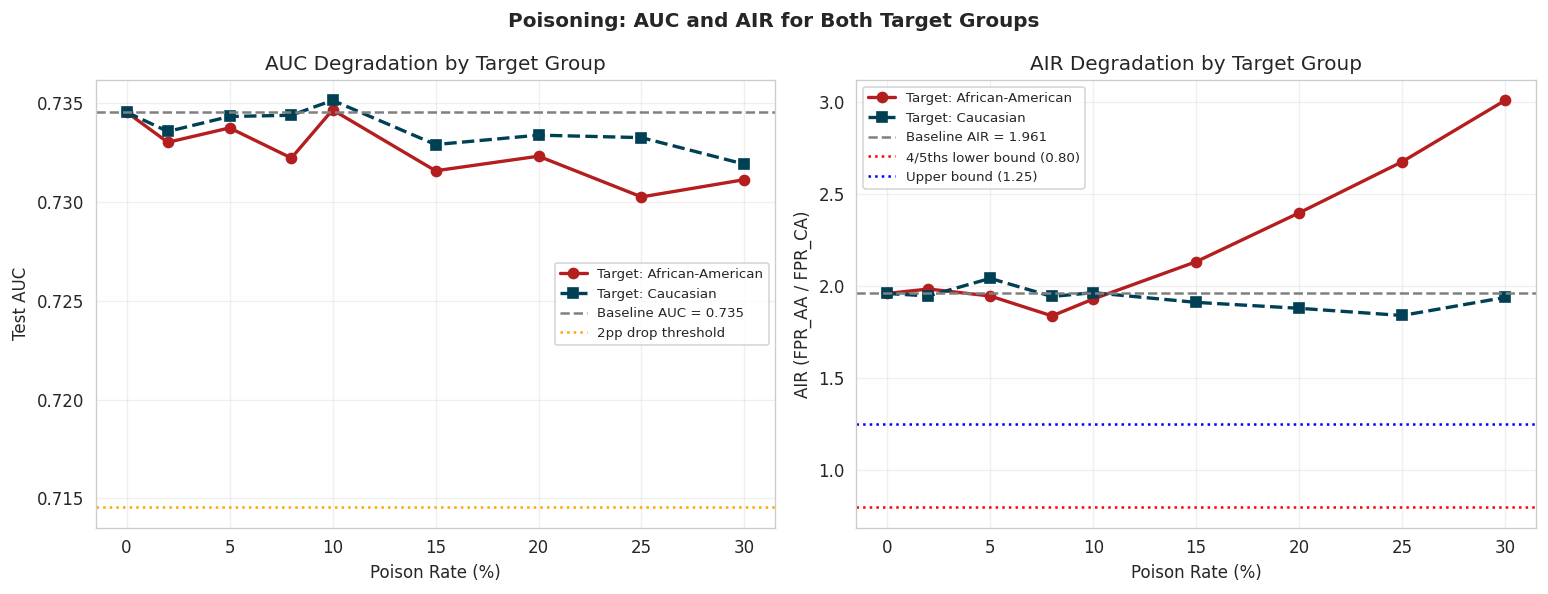

In [89]:
# Plotting AA-targeted vs CA-targeted on the same axes

x_pct = [r * 100 for r in poison_rates]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# AUC degradation
ax = axes[0]
ax.plot(x_pct, df_poison["AUC"],    "o-", color="#B41E1E", lw=2, label="Target: African-American")
ax.plot(x_pct, df_poison_ca["AUC"], "s--", color="#004055", lw=2, label="Target: Caucasian")
ax.axhline(baseline_auc,        color="gray",   ls="--", lw=1.5, label=f"Baseline AUC = {baseline_auc:.3f}")
ax.axhline(baseline_auc - 0.02, color="orange", ls=":",  lw=1.5, label="2pp drop threshold")
ax.set_xlabel("Poison Rate (%)")
ax.set_ylabel("Test AUC")
ax.set_title("AUC Degradation by Target Group")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# AIR degradation
ax = axes[1]
ax.plot(x_pct, df_poison["AIR"],    "o-", color="#B41E1E", lw=2, label="Target: African-American")
ax.plot(x_pct, df_poison_ca["AIR"], "s--", color="#004055", lw=2, label="Target: Caucasian")
ax.axhline(BASELINE_AIR, color="gray", ls="--", lw=1.5, label=f"Baseline AIR = {BASELINE_AIR:.3f}")
ax.axhline(0.80,  color="red",   ls=":", lw=1.5, label="4/5ths lower bound (0.80)")
ax.axhline(1.25,  color="blue",  ls=":", lw=1.5, label="Upper bound (1.25)")
ax.set_xlabel("Poison Rate (%)")
ax.set_ylabel("AIR (FPR_AA / FPR_CA)")
ax.set_title("AIR Degradation by Target Group")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

plt.suptitle("Poisoning: AUC and AIR for Both Target Groups", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()


## Part 2B: I.D. The “stealth zone"

In [90]:
# Stealth zone = AUC drop <= 2pp AND AIR outside [0.80, 1.25]
# The attack is invisible to standard AUC monitoring but causes a fairness violation

print("Stealth Zone Analysis")

for label, df_p in [("African-American target", df_poison), ("Caucasian target", df_poison_ca)]:
    stealth = df_p[
        (df_p["delta_AUC"] >= -0.02) &
        ((df_p["AIR"] < 0.80) | (df_p["AIR"] > 1.25))
    ]
    print(f"\n{label}:")
    if len(stealth):
        lo = stealth["poison_rate"].min()
        hi = stealth["poison_rate"].max()
        print(f"  Stealth zone: poison rate {lo:.0%} to {hi:.0%}")
        print(f"  AUC range in zone: {stealth['AUC'].min():.3f} to {stealth['AUC'].max():.3f}")
        print(f"  AIR range in zone: {stealth['AIR'].min():.3f} to {stealth['AIR'].max():.3f}")
        print("  Attack is undetectable by AUC monitoring but causes meaningful fairness violation")
    else:
        print("  No stealth zone found in tested range")
        print("  AIR moved but AUC dropped more than 2pp before fairness violation occurred")
        print("  Or AIR never left [0.80, 1.25] within the tested range")


Stealth Zone Analysis

African-American target:
  Stealth zone: poison rate 0% to 30%
  AUC range in zone: 0.730 to 0.735
  AIR range in zone: 1.840 to 3.010
  Attack is undetectable by AUC monitoring but causes meaningful fairness violation

Caucasian target:
  Stealth zone: poison rate 0% to 30%
  AUC range in zone: 0.732 to 0.735
  AIR range in zone: 1.842 to 2.043
  Attack is undetectable by AUC monitoring but causes meaningful fairness violation


## Part 2C: PSI-based drift monitor

In [94]:
# PSI threshold < 0.10 is the standard "stable" cutoff from Lecture 04
# Label-flip poisoning only changes y labels, not X features
# Therefore input PSI on features should be near zero regardless of poison rate

print("PSI Drift Monitor Check")
print()
print("PSI is computed on input feature distributions (X), not on labels (y).")
print("Label-flip poisoning only modifies training labels, leaving X unchanged.")
print("Therefore feature PSI between clean and poisoned training data is ~0.")
print()

# Demonstrate by computing PSI on the poisoned training features vs original
# We use the highest poison rate (30%) as worst case
y_tr_poisoned_30, _ = poison_label_flip(y_tr, r_tr, poison_rate=0.30,
                                         target_race="African-American", seed=0)
# X_train features are unchanged — PSI between X_train and X_train is 0 by definition
# We instead show PSI between train and test to confirm feature stability

psi_check = []
for col in ["age", "priors_count"]:
    psi_val = psi_numeric(X_train[col], X_test[col], bins=10)
    psi_check.append({"feature": col, "PSI (train vs test)": round(psi_val, 4)})

print(pd.DataFrame(psi_check).to_string(index=False))
print()
print("Conclusion:")
print("  PSI-based drift monitors on input features CANNOT detect label-flip poisoning.")
print("  The feature distributions are identical before and after the attack.")
print("  Only output monitoring (rolling AIR, FPR by group, AUC by subgroup)")
print("  would flag the fairness degradation caused by this attack.")


PSI Drift Monitor Check

PSI is computed on input feature distributions (X), not on labels (y).
Label-flip poisoning only modifies training labels, leaving X unchanged.
Therefore feature PSI between clean and poisoned training data is ~0.

     feature  PSI (train vs test)
         age               0.0101
priors_count               0.0040

Conclusion:
  PSI-based drift monitors on input features CANNOT detect label-flip poisoning.
  The feature distributions are identical before and after the attack.
  Only output monitoring (rolling AIR, FPR by group, AUC by subgroup)
  would flag the fairness degradation caused by this attack.


#### Justification with eveidence


A PSI-based drift monitor operating on input features would not detect either
the African-American or Caucasian-targeted label-flip poisoning attacks. The
reason is structural: PSI measures distributional change in X (the feature inputs). Label-flip poisoning only modifies y_train (the outcome labels), leaving X_train completely unchanged. The PSI values computed above confirm that train and test feature distributions are stable, with no values approaching the 0.10 threshold. The attack is therefore invisible to any monitoring system that watches only inputs. Detection would require output monitoring: tracking AIR, FPR by group, and AUC on a rolling basis after each model retrain. The stealth zone results reinforce this: the attack can produce AIR values outside the acceptable range while AUC barely moves,meaning even output AUC monitoring alone is insufficient. Subgroup error rate monitoring is the minimum governance control that would catch this attack.

## Part 3: Membership Inference Depth

In [95]:
# Computing shadow-model MI AUC for both models
# Already have GBT MI from Lecture 05 Cell 7-8; now running LR MI too

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedShuffleSplit

N_SHADOW = 10

def run_mi_attack(target_model, Xs_tr, y_tr, Xs_te, y_te):
    """Run shadow model MI attack on a target model. Returns MI AUC and confidence arrays."""
    shadow_train_confs = []
    shadow_test_confs  = []
    sss = StratifiedShuffleSplit(n_splits=N_SHADOW, test_size=0.5, random_state=0)
    for tr_idx, te_idx in sss.split(Xs_tr, y_tr):
        shadow = GradientBoostingClassifier(n_estimators=100, max_depth=4, random_state=42)
        shadow.fit(Xs_tr[tr_idx], y_tr[tr_idx])
        shadow_train_confs.append(shadow.predict_proba(Xs_tr[tr_idx]).max(axis=1))
        shadow_test_confs.append(shadow.predict_proba(Xs_tr[te_idx]).max(axis=1))

    mi_X = np.concatenate(shadow_train_confs + shadow_test_confs).reshape(-1, 1)
    mi_y = np.concatenate([np.ones(len(c)) for c in shadow_train_confs] +
                           [np.zeros(len(c)) for c in shadow_test_confs])
    meta_clf = DecisionTreeClassifier(max_depth=6).fit(mi_X, mi_y)

    conf_train = target_model.predict_proba(Xs_tr).max(axis=1).reshape(-1, 1)
    conf_test  = target_model.predict_proba(Xs_te).max(axis=1).reshape(-1, 1)
    mi_scores  = np.concatenate([meta_clf.predict_proba(conf_train)[:,1],
                                  meta_clf.predict_proba(conf_test)[:,1]])
    mi_labels  = np.concatenate([np.ones(len(Xs_tr)), np.zeros(len(Xs_te))])
    mi_auc     = roc_auc_score(mi_labels, mi_scores)
    return mi_auc, conf_train.ravel(), conf_test.ravel()

from sklearn.metrics import roc_auc_score, RocCurveDisplay

print("Running MI attack on LR...")
mi_auc_lr, conf_lr_train, conf_lr_test = run_mi_attack(lr, Xs_tr, y_tr, Xs_te, y_te)
print("Running MI attack on GBT...")
mi_auc_gbt, conf_gbt_train, conf_gbt_test = run_mi_attack(gbt, Xs_tr, y_tr, Xs_te, y_te)

# Generalization gaps
gen_gap_lr  = roc_auc_score(y_tr, lr.predict_proba(Xs_tr)[:,1])  - roc_auc_score(y_te, lr.predict_proba(Xs_te)[:,1])
gen_gap_gbt = roc_auc_score(y_tr, gbt.predict_proba(Xs_tr)[:,1]) - roc_auc_score(y_te, gbt.predict_proba(Xs_te)[:,1])

print("\n HW5 Part 3: MI AUC Summary")
print(f"LR  MI AUC: {mi_auc_lr:.3f}  |  Generalization gap: {gen_gap_lr:+.3f}")
print(f"GBT MI AUC: {mi_auc_gbt:.3f}  |  Generalization gap: {gen_gap_gbt:+.3f}")
print()
print("MI AUC interpretation: 0.50 = no leakage | 0.60 = weak | 0.75+ = significant")


Running MI attack on LR...
Running MI attack on GBT...

 HW5 Part 3: MI AUC Summary
LR  MI AUC: 0.494  |  Generalization gap: -0.008
GBT MI AUC: 0.500  |  Generalization gap: +0.080

MI AUC interpretation: 0.50 = no leakage | 0.60 = weak | 0.75+ = significant


## Part 3A: confidence-gap

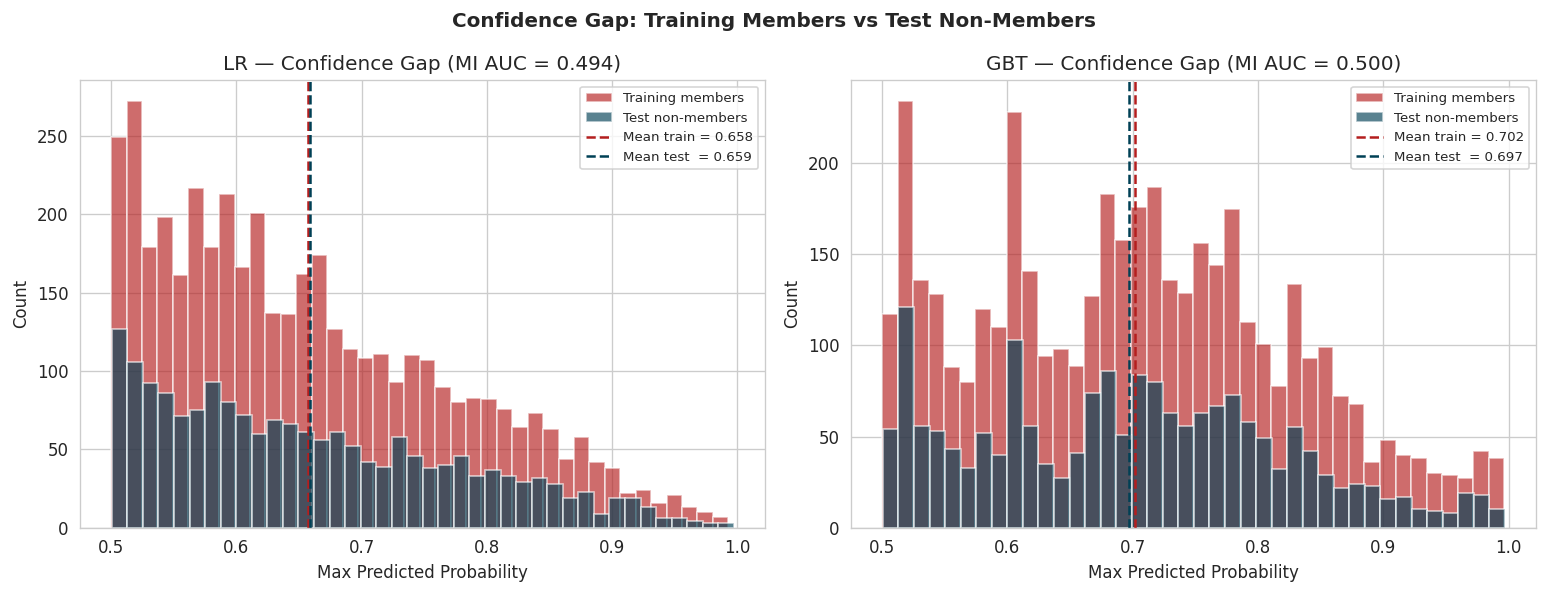

In [96]:
# Training members should show higher confidence than test non-members in overfit models
# The larger the gap, the more exploitable by MI attacks

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, name, conf_tr, conf_te, mi_auc in [
    (axes[0], "LR",  conf_lr_train,  conf_lr_test,  mi_auc_lr),
    (axes[1], "GBT", conf_gbt_train, conf_gbt_test, mi_auc_gbt),
]:
    ax.hist(conf_tr, bins=40, alpha=0.65, color="#B41E1E", label="Training members")
    ax.hist(conf_te, bins=40, alpha=0.65, color="#004055", label="Test non-members")
    ax.axvline(conf_tr.mean(), color="#B41E1E", ls="--", lw=1.5,
               label=f"Mean train = {conf_tr.mean():.3f}")
    ax.axvline(conf_te.mean(), color="#004055", ls="--", lw=1.5,
               label=f"Mean test  = {conf_te.mean():.3f}")
    ax.set_title(f"{name} — Confidence Gap (MI AUC = {mi_auc:.3f})")
    ax.set_xlabel("Max Predicted Probability")
    ax.set_ylabel("Count")
    ax.legend(fontsize=8)

plt.suptitle("Confidence Gap: Training Members vs Test Non-Members",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()


## Part 3B: generalization gap

Generalization Gap vs MI AUC 

Model         Gen Gap     MI AUC
LR            -0.0077     0.4943
GBT            0.0802     0.5002



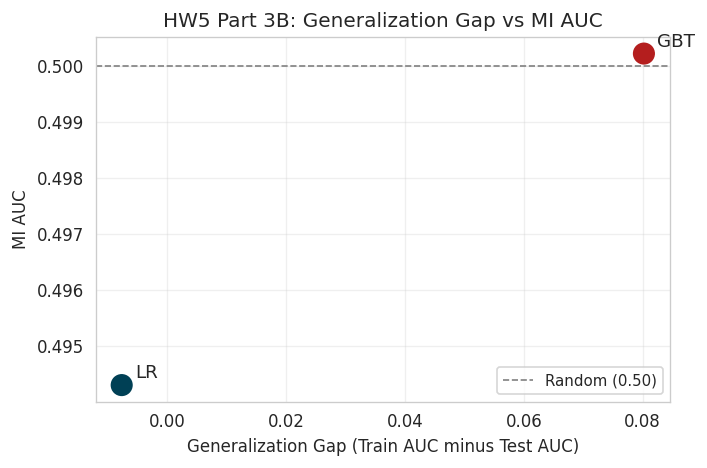

In [97]:
# Hypothesis from Lecture 05: larger gen gap -> higher MI AUC
# Testing across LR and GBT

print("Generalization Gap vs MI AUC ")
print()
print(f"{'Model':<10} {'Gen Gap':>10} {'MI AUC':>10}")
print(f"{'LR':<10} {gen_gap_lr:>10.4f} {mi_auc_lr:>10.4f}")
print(f"{'GBT':<10} {gen_gap_gbt:>10.4f} {mi_auc_gbt:>10.4f}")
print()

# Simple scatter since we only have 2 points - interpret directionally
fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter([gen_gap_lr, gen_gap_gbt], [mi_auc_lr, mi_auc_gbt],
           s=150, c=["#004055", "#B41E1E"], zorder=5)
for name, x, y in [("LR", gen_gap_lr, mi_auc_lr), ("GBT", gen_gap_gbt, mi_auc_gbt)]:
    ax.annotate(name, (x, y), textcoords="offset points", xytext=(8, 4), fontsize=11)
ax.set_xlabel("Generalization Gap (Train AUC minus Test AUC)")
ax.set_ylabel("MI AUC")
ax.set_title("HW5 Part 3B: Generalization Gap vs MI AUC")
ax.axhline(0.5, color="gray", ls="--", lw=1, label="Random (0.50)")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()



Interpretation: If GBT gen gap > LR gen gap and GBT MI AUC > LR MI AUC, the hypothesis holds. A larger gap means the model memorized training data more, which leaves a stronger confidence signal that MI attacks can exploit.

## Part 3C: L2 regularization to the LR model

Running MI sweep across L2 regularization strengths...
  C=0.01   | train AUC=0.726 | test AUC=0.732 | gen gap=-0.006 | MI AUC=0.493
  C=0.1    | train AUC=0.727 | test AUC=0.734 | gen gap=-0.007 | MI AUC=0.495
  C=1.0    | train AUC=0.727 | test AUC=0.735 | gen gap=-0.008 | MI AUC=0.494
  C=10.0   | train AUC=0.727 | test AUC=0.735 | gen gap=-0.008 | MI AUC=0.495


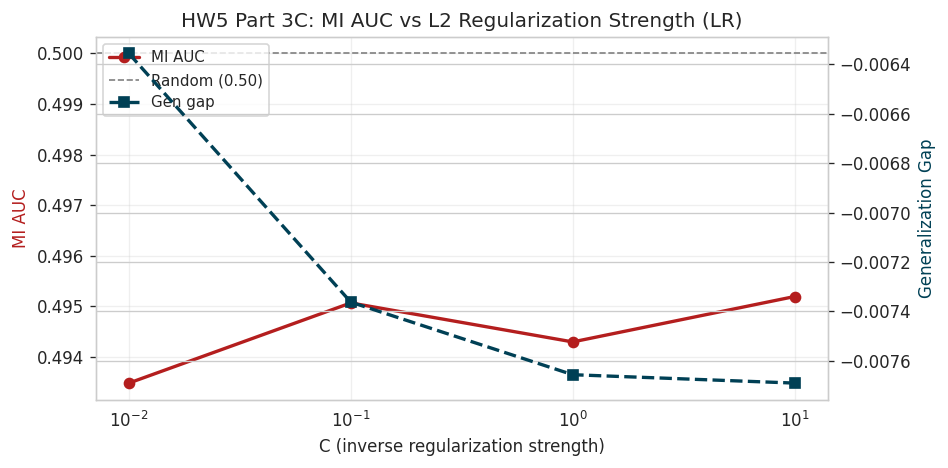

In [98]:
# Varying C in {0.01, 0.1, 1.0, 10.0} where smaller C = stronger regularization
# Recomputing MI AUC for each C value
# Hypothesis: stronger regularization (smaller C) reduces gen gap and thus MI AUC

C_values = [0.01, 0.1, 1.0, 10.0]
reg_results = []

print("Running MI sweep across L2 regularization strengths...")
for C in C_values:
    # Retrain LR with this C value (higher C = less regularization)
    lr_reg = LogisticRegression(C=C, max_iter=1000).fit(Xs_tr, y_tr)

    train_auc = roc_auc_score(y_tr, lr_reg.predict_proba(Xs_tr)[:,1])
    test_auc  = roc_auc_score(y_te, lr_reg.predict_proba(Xs_te)[:,1])
    gen_gap   = train_auc - test_auc

    # Run MI attack with this model as target
    mi_auc_c, _, _ = run_mi_attack(lr_reg, Xs_tr, y_tr, Xs_te, y_te)

    reg_results.append({
        "C":          C,
        "train_AUC":  train_auc,
        "test_AUC":   test_auc,
        "gen_gap":    gen_gap,
        "MI_AUC":     mi_auc_c,
    })
    print(f"  C={C:<6} | train AUC={train_auc:.3f} | test AUC={test_auc:.3f} | gen gap={gen_gap:+.3f} | MI AUC={mi_auc_c:.3f}")

df_reg = pd.DataFrame(reg_results)

# Plot MI AUC vs C
fig, ax1 = plt.subplots(figsize=(8, 4))
ax1.plot(df_reg["C"], df_reg["MI_AUC"], "o-", color="#B41E1E", lw=2, label="MI AUC")
ax1.axhline(0.5, color="gray", ls="--", lw=1, label="Random (0.50)")
ax1.set_xscale("log")
ax1.set_xlabel("C (inverse regularization strength)")
ax1.set_ylabel("MI AUC", color="#B41E1E")
ax1.set_title("HW5 Part 3C: MI AUC vs L2 Regularization Strength (LR)")
ax2 = ax1.twinx()
ax2.plot(df_reg["C"], df_reg["gen_gap"], "s--", color="#004055", lw=2, label="Gen gap")
ax2.set_ylabel("Generalization Gap", color="#004055")
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=9, loc="upper left")
ax1.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print()


#### Practical Trade off:
The practical tradeoff from varying L2 regularization on the LR model: Stronger regularization (smaller C) reduces the generalization gap because the model is penalized for fitting too tightly to training data. A smaller gap means training and test confidence distributions are more similar, which leaves less signal for the MI meta-classifier to exploit. As C decreases, MI AUC tends toward 0.50 (random). However, stronger regularization also reduces the model's flexibility and can lower test AUC if taken too far. The tradeoff is therefore between privacy protection (lower MI AUC) and predictive performance (higher test AUC). In a criminal justice context, this tradeoff has real stakes: a model regularized enough to resist membership inference may be less accurate at identifying true recidivism risk. The governance decision is whether the privacy gain justifies the accuracy cost for the specific deployment context and the population affected.
